In [ ]:
import os
import requests
import zipfile
import io
from scipy.stats import wilcoxon
import torch
import re, math, json, time, random
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any
import spacy
import numpy as np
import glob
# Expect you already loaded spaCy in your notebook:
nlp = spacy.load("en_core_web_sm")

# --- Configuration ---
ZENODO_RECORD_ID = "7118517"
FILE_NAME = "requirements-xml.zip"
DOWNLOAD_URL = f"https://zenodo.org/records/{ZENODO_RECORD_ID}/files/{FILE_NAME}?download=1"
EXTRACT_FOLDER = "pure_dataset_xml"
import random
import numpy as np
import os
import re
assert "nlp" in globals()
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("Global Seed Set: 42")
def download_and_extract():
    """Downloads the dataset and extracts it to a folder."""
    if os.path.exists(EXTRACT_FOLDER):
        print(f"Folder '{EXTRACT_FOLDER}' already exists. Skipping download.")
        return

    print(f"Downloading {FILE_NAME} from Zenodo...")
    try:
        response = requests.get(DOWNLOAD_URL)
        response.raise_for_status() # Check for HTTP errors
        
        print("Download complete. Extracting files...")
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            z.extractall(EXTRACT_FOLDER)
        print(f"Files extracted to '{EXTRACT_FOLDER}'.")
        
    except Exception as e:
        print(f"Error during download/extraction: {e}")

# Run the function
download_and_extract()

Global Seed Set: 42
Folder 'pure_dataset_xml' already exists. Skipping download.


In [2]:
import os
import re
import xml.etree.ElementTree as ET

REQ_PAT = re.compile(r"\b(shall|must|should|required|is required to|are required to|needs to|need to)\b", re.I)

def split_sentences(s: str):
    # simple but decent; avoids empty chunks
    parts = re.split(r"(?<=[.!?])\s+", s)
    return [p.strip() for p in parts if p.strip()]

def parse_xml_files(folder_path, max_files=None, max_sent_per_file=None):
    xml_files = []
    for dirpath, _, filenames in os.walk(folder_path):
        for fn in filenames:
            if fn.lower().endswith(".xml"):
                xml_files.append(os.path.join(dirpath, fn))

    if max_files:
        xml_files = xml_files[:max_files]

    texts = []
    lengths = []
    parse_fail = 0

    for fp in xml_files:
        try:
            root = ET.parse(fp).getroot()
            full = " ".join(root.itertext())
        except Exception:
            parse_fail += 1
            continue

        full = re.sub(r"\s+", " ", full).strip()
        sents = split_sentences(full)

        kept = 0
        for sent in sents:
            if REQ_PAT.search(sent):
                texts.append(sent)
                lengths.append(len(sent.split()))
                kept += 1
                if max_sent_per_file and kept >= max_sent_per_file:
                    break

    print("XML files:", len(xml_files), "| Parse failed:", parse_fail, "| Kept sentences:", len(texts))
    return texts, lengths

print("Parsing XML files...")
texts, lengths = parse_xml_files(EXTRACT_FOLDER, max_files=None, max_sent_per_file=200)
print(f"Extracted {len(texts)} requirement-like sentences.")

Parsing XML files...
XML files: 36 | Parse failed: 18 | Kept sentences: 1787
Extracted 1787 requirement-like sentences.


In [3]:
text_data, lengths = parse_xml_files(EXTRACT_FOLDER)
print("snippets:", len(text_data), "avg_wc:", sum(lengths)/max(1,len(lengths)))

XML files: 36 | Parse failed: 18 | Kept sentences: 2821
snippets: 2821 avg_wc: 26.43069833392414


Loading Cornelius_2025_user_story_ambiguity_dataset.xlsx...
   - Found 12847 stories.
   - 4327 are marked as Ambiguous (HasAmbiguity=1)
 - Ambiguity breakdown:
     * SemanticAmbiguity: 2831
     * ScopeAmbiguity: 1301
     * ActorAmbiguity: 865
     * PriorityAmbiguity: 110

 --- Analysis of Cornelius Dataset ---


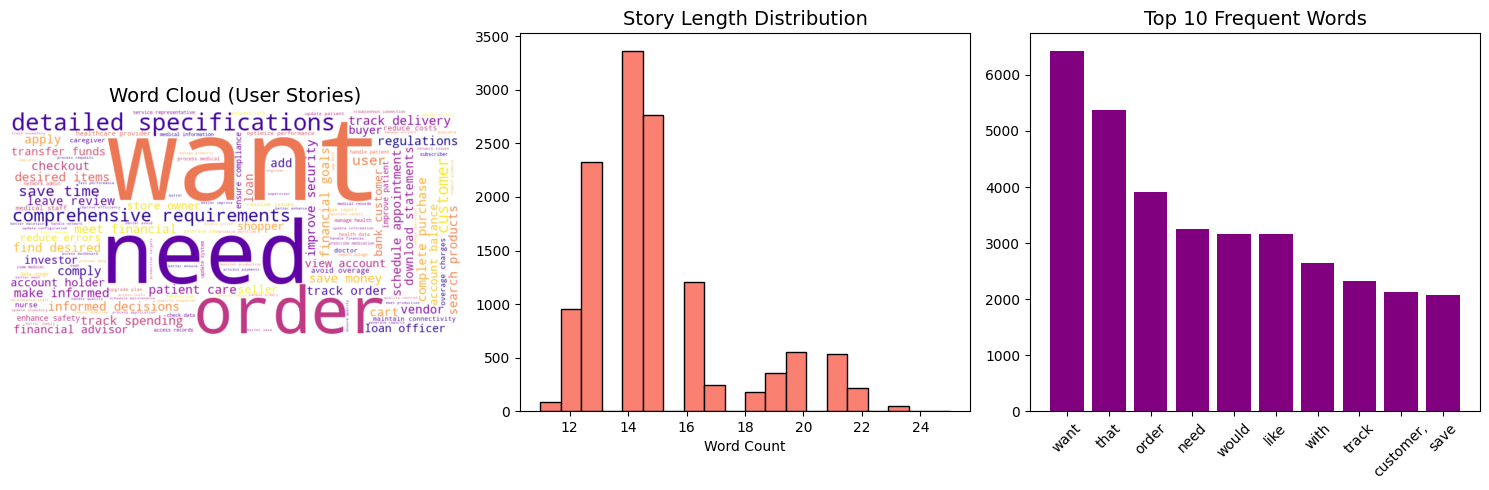

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# --- Configuration ---
# Ensure the file name matches exactly what you have in your folder
CORNELIUS_FILE = "Cornelius_2025_user_story_ambiguity_dataset.xlsx"

def load_cornelius_data(file_path):
    """
    Loads the Cornelius User Story dataset using the specific columns found.
    """
    if not os.path.exists(file_path):
        print(f"File '{file_path}' not found! Please check the path.")
        return [], []

    print(f"Loading {file_path}...")
    try:
        df = pd.read_excel(file_path)
        
        # --- FIX: explicit column mapping based on your error message ---
        text_col = 'StoryText'
        label_col = 'HasAmbiguity' # 1 = Ambiguous, 0 = Not Ambiguous
        
        # Verify columns exist
        if text_col not in df.columns:
             print(f"Still cannot find '{text_col}'. Columns are: {list(df.columns)}")
             return [], []

        # Drop rows with missing text
        df = df.dropna(subset=[text_col])
        
        # Get data
        text_data = df[text_col].astype(str).tolist()
        labels = df[label_col].tolist() if label_col in df.columns else []
        
        # Optional: Print stats about ambiguity
        if labels:
            ambiguous_count = sum(labels)
            print(f"   - Found {len(text_data)} stories.")
            print(f"   - {ambiguous_count} are marked as Ambiguous (HasAmbiguity=1)")
            
            # Check for specific ambiguity types if they exist
            types = ['SemanticAmbiguity', 'ScopeAmbiguity', 'ActorAmbiguity', 'PriorityAmbiguity']
            print(" - Ambiguity breakdown:")
            for t in types:
                if t in df.columns:
                    print(f"     * {t}: {df[t].sum()}")

        return text_data, labels

    except Exception as e:
        print(f" Error reading Excel file: {e}")
        return [], []

# --- Execution & Visualization ---
cornelius_texts, cornelius_labels = load_cornelius_data(CORNELIUS_FILE)

if cornelius_texts:
    print(f"\n --- Analysis of Cornelius Dataset ---")
    
    # 1. Word Cloud
    long_string = " ".join(cornelius_texts)
    # Using a different colormap 'plasma' to distinguish from PURE
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(long_string)
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Word Cloud
    plt.subplot(1, 3, 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud (User Stories)", fontsize=14)
    
    # Plot 2: Length Histogram
    lengths = [len(t.split()) for t in cornelius_texts]
    plt.subplot(1, 3, 2)
    plt.hist(lengths, bins=20, color='salmon', edgecolor='black')
    plt.xlabel("Word Count")
    plt.title("Story Length Distribution", fontsize=14)
    
    # Plot 3: Top Words
    all_words = [w.lower() for w in long_string.split() if len(w) > 3]
    common_words = Counter(all_words).most_common(10)
    words, counts = zip(*common_words)
    
    plt.subplot(1, 3, 3)
    plt.bar(words, counts, color='purple')
    plt.xticks(rotation=45)
    plt.title("Top 10 Frequent Words", fontsize=14)
    
    plt.tight_layout()
    plt.show()

In [5]:
# Simple print to compare the two datasets' scale
print(f"--- Dataset Comparison ---")
# Assuming 'text_data' is your variable from the PURE code block
try:
    print(f"PURE Dataset:      {len(text_data)} documents") 
except NameError:
    print("PURE Dataset:      (Not loaded in memory)")

print(f"Cornelius Dataset: {len(cornelius_texts)} user stories")

--- Dataset Comparison ---
PURE Dataset:      2821 documents
Cornelius Dataset: 12847 user stories


In [6]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import time

# --- Configuration ---
# 'all-MiniLM-L6-v2' is excellent for efficiency/performance balance.
# For the final paper, you might switch to 'BAAI/bge-m3' for higher accuracy.
MODEL_NAME = 'Qwen/Qwen3-Embedding-0.6B'

def generate_embeddings(text_list, model_name):
    """
    Encodes a list of text strings into vectors.
    """
    print(f"Loading model: {model_name}...")
    model = SentenceTransformer(model_name)
    
    print(f"Encoding {len(text_list)} documents... (This may take a moment)")
    t0 = time.time()
    embeddings = model.encode(text_list, convert_to_numpy=True, show_progress_bar=True)
    print(f"Encoding complete in {time.time()-t0:.2f}s. Shape: {embeddings.shape}")
    
    return embeddings, model

# 1. Prepare Data
# Ensure df_pure and cornelius_texts are available from previous steps!
# We drop any potential NaNs just in case
df_pure = pd.DataFrame({'text': text_data}) # Assuming text_data is from the PURE processing step
kb_texts = df_pure['text'].dropna().tolist()
query_texts = cornelius_texts # From the Cornelius loading step

# 2. Run Encoding
# We use the same model for both to ensure they are in the same vector space
embeddings_kb, embedding_model = generate_embeddings(kb_texts, MODEL_NAME)
embeddings_queries, _ = generate_embeddings(query_texts, MODEL_NAME)

Loading model: Qwen/Qwen3-Embedding-0.6B...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Encoding 2821 documents... (This may take a moment)


Batches:   0%|          | 0/89 [00:00<?, ?it/s]

Encoding complete in 7.55s. Shape: (2821, 1024)
Loading model: Qwen/Qwen3-Embedding-0.6B...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Encoding 12847 documents... (This may take a moment)


Batches:   0%|          | 0/402 [00:00<?, ?it/s]

Encoding complete in 23.93s. Shape: (12847, 1024)


In [7]:
def run_retrieval_analysis(kb_embeddings, query_embeddings, k_max=50):
    """
    Retrieves top k_max documents for every query and returns the distances.
    """
    d = kb_embeddings.shape[1] # Dimension of the vector (e.g., 384)
    
    # Initialize FAISS Index (L2 Distance -> Euclidean)
    # Note: For Cosine similarity, we usually normalize vectors. 
    # MiniLM produces normalized vectors by default, so L2 is directly related to Cosine.
    index = faiss.IndexFlatL2(d) 
    index.add(kb_embeddings)
    
    print(f" Indexed {index.ntotal} documents.")
    
    print(f" Searching for nearest neighbors (k={k_max})...")
    # D = Distances (lower is better for L2), I = Indices of matches
    D, I = index.search(query_embeddings, k_max)
    
    return D, I

# Run search looking for top 50 matches to analyze the drop-off
k_test = 50
D, I = run_retrieval_analysis(embeddings_kb, embeddings_queries, k_max=k_test)

 Indexed 2821 documents.
 Searching for nearest neighbors (k=50)...


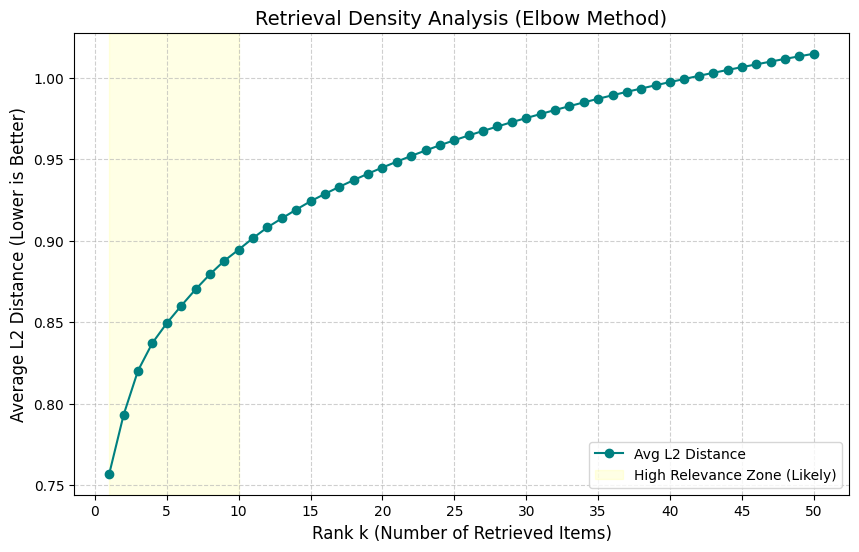

Interpretation:
1. The steep rise on the left shows that the first few results are much closer than the rest.
2. The point where the curve 'bends' or flattens is your Optimal k.
(Adding more k after this point adds mostly noise/distance).


In [8]:
import matplotlib.pyplot as plt

def plot_retrieval_density(distances, k_max):
    """
    Plots the average distance at each rank to find the 'elbow'.
    """
    # 1. Convert L2 distance to Similarity (Approximate for visualization)
    # Sim = 1 / (1 + Distance) is a common proxy, or just plot Distance directly.
    # Lower Distance = Higher Similarity.
    
    avg_distances = np.mean(distances, axis=0)
    
    plt.figure(figsize=(10, 6))
    
    # Plot the curve
    plt.plot(range(1, k_max + 1), avg_distances, marker='o', linestyle='-', color='teal', label='Avg L2 Distance')
    
    # Formatting
    plt.title("Retrieval Density Analysis (Elbow Method)", fontsize=14)
    plt.xlabel("Rank k (Number of Retrieved Items)", fontsize=12)
    plt.ylabel("Average L2 Distance (Lower is Better)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(np.arange(0, k_max + 1, 5))
    
    # --- INTERPRETATION HELPER ---
    # We want to find where the curve starts to flatten out (diminishing returns).
    # Let's highlight the top 5-10 zone
    plt.axvspan(1, 10, color='yellow', alpha=0.1, label='High Relevance Zone (Likely)')
    
    plt.legend()
    plt.show()
    
    print("Interpretation:")
    print("1. The steep rise on the left shows that the first few results are much closer than the rest.")
    print("2. The point where the curve 'bends' or flattens is your Optimal k.")
    print("(Adding more k after this point adds mostly noise/distance).")

plot_retrieval_density(D, k_test)

In [9]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def manual_mmr(query_embedding, candidate_embeddings, k=5, diversity=0.7):
    """
    A manual implementation of Maximal Marginal Relevance.
    
    query_embedding: 2D array (1, dim)
    candidate_embeddings: 2D array (num_candidates, dim)
    k: Number of documents to retrieve
    diversity: 0 to 1 (lambda in the formula is 1 - diversity)
    """
    # 1. Calculate similarities of all candidates to the query
    # relevance_scores shape: (num_candidates,)
    relevance_scores = cosine_similarity(candidate_embeddings, query_embedding).flatten()
    
    # 2. Calculate similarities between all candidates (for redundancy check)
    # item_to_item_sim shape: (num_candidates, num_candidates)
    item_to_item_sim = cosine_similarity(candidate_embeddings)
    
    selected_indices = []
    unselected_indices = list(range(len(candidate_embeddings)))
    
    # λ (lambda) in MMR formula: 1 - diversity
    # MMR = λ * sim(doc, query) - (1-λ) * max_sim(doc, selected_docs)
    lam = 1 - diversity
    
    # Start by picking the single most relevant document
    best_first_idx = np.argmax(relevance_scores)
    selected_indices.append(best_first_idx)
    unselected_indices.remove(best_first_idx)
    
    # Iteratively pick the next k-1 documents
    while len(selected_indices) < k and unselected_indices:
        mmr_scores = []
        
        for idx in unselected_indices:
            relevance = relevance_scores[idx]
            # Find the max similarity this document has with already selected documents
            redundancy = max([item_to_item_sim[idx][sel] for sel in selected_indices])
            
            # MMR formula
            score = lam * relevance - (1 - lam) * redundancy
            mmr_scores.append((score, idx))
        
        # Pick the one with the highest MMR score
        next_idx = max(mmr_scores, key=lambda x: x[0])[1]
        
        selected_indices.append(next_idx)
        unselected_indices.remove(next_idx)
        
    return selected_indices

def search_mmr(kb_embeddings, query_embedding, k=5, diversity=0.7):
    """
    Wraps the manual MMR logic into your RAG pipeline.
    """
    # Ensure 2D
    if len(query_embedding.shape) == 1:
        query_embedding = query_embedding.reshape(1, -1)
        
    # 1. Initial Retrieval: Get a larger pool of candidates (top 50)
    # Using cosine similarity to find the initial pool
    all_sims = cosine_similarity(kb_embeddings, query_embedding).flatten()
    candidate_pool_indices = np.argsort(all_sims)[-50:][::-1] # Top 50 indices
    
    candidate_embeddings = kb_embeddings[candidate_pool_indices]
    
    # 2. Re-rank the pool using MMR
    selected_local_indices = manual_mmr(
        query_embedding, 
        candidate_embeddings, 
        k=k, 
        diversity=diversity
    )
    
    # 3. Map back to global indices
    final_indices = [candidate_pool_indices[idx] for idx in selected_local_indices]
    
    return final_indices

print("Manual MMR search function is ready.")

Manual MMR search function is ready.


In [10]:
import random
import torch
from sentence_transformers import util

# --- CONFIGURATION ---
TEST_K = 5
TEST_DIVERSITY = 0.7  # Try changing this to 0.2 (more repetitive) or 0.9 (wildly different)

# Pick a random query from Cornelius dataset
idx = random.randint(0, len(embeddings_queries)-1)
query_text = query_texts[idx]
query_vec = embeddings_queries[idx]

print(f" QUERY: \"{query_text}\"")
print("-" * 80)

# 1. Standard Top-k (Pure Relevance)
print(f"1️  STANDARD TOP-{TEST_K} (Pure Relevance)")
# We use the search_mmr function with diversity=0 to simulate standard search, or just util.semantic_search
standard_hits = util.semantic_search(torch.tensor(query_vec).unsqueeze(0), torch.tensor(embeddings_kb), top_k=TEST_K)[0]
for i, hit in enumerate(standard_hits):
    doc_id = hit['corpus_id']
    score = hit['score']
    print(f"   {i+1}. [{score:.4f}] {kb_texts[doc_id][:120]}...")

print("-" * 80)

# 2. MMR (Relevance + Diversity)
print(f"2️  MMR TOP-{TEST_K} (Diversity={TEST_DIVERSITY})")
mmr_indices = search_mmr(embeddings_kb, query_vec, k=TEST_K, diversity=TEST_DIVERSITY)

for i, doc_id in enumerate(mmr_indices):
    print(f"   {i+1}. [MMR Selected] {kb_texts[doc_id][:120]}...")

print("\n(Note: If MMR picks different documents, it means it skipped a redundant one to find a different perspective.)")

 QUERY: "As a customer, I want to apply for loan so that I can improve security"
--------------------------------------------------------------------------------
1️  STANDARD TOP-5 (Pure Relevance)
   1. [0.5788] This shall ensure that unauthorized usage of an individuals’ identity is avoided....
   2. [0.5620] The transactions must be performed with high level of security....
   3. [0.5482] The transactions must be performed with high level of security and reliability....
   4. [0.5442] There should be security preventing the intrusion into the system by unauthorized users, or users at unauthorized access...
   5. [0.5405] What security technologies are required, how the system will response in each user’s action etc....
--------------------------------------------------------------------------------
2️  MMR TOP-5 (Diversity=0.7)
   1. [MMR Selected] This shall ensure that unauthorized usage of an individuals’ identity is avoided....
   2. [MMR Selected] Later if the account needs to 

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

df_experiment = pd.DataFrame({
    "uid": np.arange(len(cornelius_texts), dtype=int),  # stable unique id
    "text": cornelius_texts,
    "label": cornelius_labels
})

df_dev, df_test = train_test_split(
    df_experiment,
    test_size=0.20,
    stratify=df_experiment["label"],
    random_state=RANDOM_SEED
)

# 3. Further split Dev into a small Validation set for Hyperparameter Optimization
df_val = df_dev.sample(n=200, random_state=RANDOM_SEED)

print(f" Data Split Complete:")
print(f"   - Validation Set (HPO): {len(df_val)} samples")
print(f"   - Final Test Set:       {len(df_test)} samples")
print(f"   - Ambiguity Ratio:      {df_test['label'].mean():.2%}")

 Data Split Complete:
   - Validation Set (HPO): 200 samples
   - Final Test Set:       2570 samples
   - Ambiguity Ratio:      33.70%


In [12]:
from sentence_transformers import util
from rouge_score import rouge_scorer
import numpy as np

class RAGEvaluator:
    def __init__(self, embedding_model):
        self.model = embedding_model
        self.scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    def get_semantic_similarity(self, text1, text2):
        """Measures intent preservation via cosine similarity."""
        emb1 = self.model.encode(text1, convert_to_tensor=True)
        emb2 = self.model.encode(text2, convert_to_tensor=True)
        return util.cos_sim(emb1, emb2).item()

    def get_smell_reduction(self, original_smells, new_smells):
        """Measures the reduction in linguistic issues."""
        return original_smells - new_smells

    def evaluate_sample(self, original, rewritten, orig_smell_count, new_smell_count):
        """Returns a dictionary of all metrics for one sample."""
        return {
            "semantic_sim": self.get_semantic_similarity(original, rewritten),
            "rougeL": self.scorer.score(original, rewritten)['rougeL'].fmeasure,
            "smell_reduction": orig_smell_count - new_smell_count,
            "is_improved": new_smell_count < orig_smell_count
        }

# Initialize the evaluator
evaluator = RAGEvaluator(embedding_model)
print(" Evaluation Suite Initialized.")

 Evaluation Suite Initialized.


In [13]:
import spacy
from spacy.matcher import Matcher

# Load spaCy model (English)
try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")


In [14]:
def rule_based_ambiguity_check(text, doc=None):
    if doc is None:
        doc = nlp(str(text))
    smells = []

    vague_adjectives = {'easy','fast','quick','user-friendly','efficient','flexible','robust','appropriate','clear','minimal'}
    weak_modals = {'should','could','might','may','would'}
    quantifiers = {'some','any','most','many','all','few','several'}
    escape_words = {'if','when','where','possibly','unless','except','necessary'}

    # 1) Subjective adjectives
    for token in doc:
        if token.pos_ == "ADJ" and token.text.lower() in vague_adjectives:
            smells.append(("subjective_adj", f"Subjective Adjective: {token.text}"))

    # 2) Passive voice
    matcher = Matcher(nlp.vocab)
    passive_rule = [{"DEP": "auxpass"}, {"TAG": "VBN"}]
    matcher.add("PASSIVE_VOICE", [passive_rule])
    if len(matcher(doc)) > 0:
        smells.append(("passive", "Passive Voice (Missing Actor)"))

    # 3) Non-atomicity
    conjunctions = [t for t in doc if t.pos_ == "CCONJ" and t.text.lower() in ['and','or']]
    if len(conjunctions) >= 1:  # was >1; >=1 catches typical “and/or” multi-req
        smells.append(("non_atomic", "Non-Atomic (Multiple Requirements combined)"))

    # 4) Escape clauses
    for token in doc:
        if token.text.lower() in escape_words and token.dep_ in ['mark','advmod']:
            smells.append(("escape", f"Escape Clause: {token.text}"))

    # 5) Vague quantifiers
    for token in doc:
        if token.text.lower() in quantifiers and token.pos_ in ['DET','PRON']:
            smells.append(("quantifier", f"Vague Quantifier: {token.text}"))

    # 6) Weak modals
    for token in doc:
        if token.text.lower() in weak_modals:
            smells.append(("weak_modal", f"Weak Modal: {token.text}"))

    # unique by string, but keep category counts
    smell_strings = sorted(set(s for _, s in smells))
    cat_counts = {}
    for cat, s in smells:
        cat_counts[cat] = cat_counts.get(cat, 0) + 1

    return {
        "smell_count": len(smell_strings),
        "smell_list": smell_strings,
        "category_counts": cat_counts
    }

In [15]:
# --- Optimized HPO with Context Relevance ---
hpo_results = []

# Pre-encode val set for speed (if not already done)
val_texts = df_val['text'].tolist()
val_embeddings = embedding_model.encode(val_texts, show_progress_bar=True)

for k in [3, 5, 7]:
    for lam in [0.3, 0.5, 0.7]:
        similarities = []
        for i in range(len(val_texts)):
            query_vec = val_embeddings[i].reshape(1, -1)
            # Retrieve using MMR
            indices = search_mmr(embeddings_kb, query_vec, k=k, diversity=1-lam)
            
            # Check similarity of retrieved requirements to original
            context_vecs = embeddings_kb[indices]
            sims = cosine_similarity(query_vec, context_vecs).flatten()
            similarities.append(np.mean(sims))
            
        hpo_results.append({'k': k, 'lambda': lam, 'score': np.mean(similarities)})
        print(f"Tested: k={k}, λ={lam} | Score: {np.mean(similarities):.4f}")

df_hpo = pd.DataFrame(hpo_results)
best_params = df_hpo.loc[df_hpo['score'].idxmax()]
FINAL_K, FINAL_LAMBDA = int(best_params['k']), best_params['lambda']
print(f" Best Params: k={FINAL_K}, λ={FINAL_LAMBDA}")

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Tested: k=3, λ=0.3 | Score: 0.5491
Tested: k=3, λ=0.5 | Score: 0.5562
Tested: k=3, λ=0.7 | Score: 0.5820
Tested: k=5, λ=0.3 | Score: 0.5348
Tested: k=5, λ=0.5 | Score: 0.5442
Tested: k=5, λ=0.7 | Score: 0.5687
Tested: k=7, λ=0.3 | Score: 0.5290
Tested: k=7, λ=0.5 | Score: 0.5390
Tested: k=7, λ=0.7 | Score: 0.5607
 Best Params: k=3, λ=0.7


In [16]:
MIN_WORDS = 12
MAX_WORDS = 30

def constraint_block(min_words=MIN_WORDS, max_words=MAX_WORDS):
    return f"""
CONSTRAINTS:
- Output exactly ONE sentence.
- Start exactly with: "The system shall"
- {min_words}–{max_words} words.
- Active voice.
- No weak modals: should/could/may/might/would/can.
- Avoid vague quantifiers and subjective adjectives.
- Keep it atomic: do not combine multiple independent requirements with "and/or".
Return ONLY the requirement text.
""".strip()

In [17]:
import time, random
import httpx
from huggingface_hub.utils import HfHubHTTPError

RETRYABLE = {408, 409, 425, 429, 500, 502, 503, 504}

def _status_code(e):
    # HuggingFace Hub error may carry response
    if isinstance(e, HfHubHTTPError):
        resp = getattr(e, "response", None)
        if resp is not None:
            return getattr(resp, "status_code", None)
    if isinstance(e, httpx.HTTPStatusError):
        return e.response.status_code
    return None

def hf_chat_completion(messages, max_tokens=80, temperature=0.0, retries=8, base_sleep=1.5):
    """
    Wraps client.chat_completion with exponential backoff.
    Also shrinks max_tokens on retries (reduces server work).
    """
    mt = int(max_tokens)
    last = None

    for attempt in range(retries):
        try:
            # NOTE: some HF clients accept timeout=..., some don't.
            # If yours supports it, uncomment timeout:
            # return client.chat_completion(messages=messages, max_tokens=mt, temperature=temperature, timeout=60)
            return client.chat_completion(messages=messages, max_tokens=mt, temperature=temperature)
        except Exception as e:
            last = e
            sc = _status_code(e)
            msg = str(e)

            retry = (sc in RETRYABLE) or ("504" in msg) or ("Gateway Time-out" in msg) or ("timed out" in msg.lower())
            if not retry:
                raise

            # exponential backoff + jitter
            sleep = min(60, base_sleep * (2 ** attempt) + random.random())
            time.sleep(sleep)

            # shrink tokens gradually; keep enough for 1 sentence
            mt = max(40, int(mt * 0.85))

    raise RuntimeError(f"HF chat failed after {retries} retries. Last error: {last}")

In [18]:
import os
HF_TOKEN = os.environ["HF_TOKEN"] 


In [19]:
from huggingface_hub import InferenceClient
MIN_WORDS = 12
MAX_WORDS = 30

In [20]:
import numpy as np
from scipy.stats import entropy as shannon_entropy  # rename for clarity
from collections import Counter
import re

In [21]:
# ===================== CELL 1: robust sentence counting for validity =====================

# Replace dots that should NOT end sentences: decimals, versions, dotted acronyms, common abbreviations.
_ABBR = [
    "e.g.", "i.e.", "etc.", "vs.", "mr.", "mrs.", "dr.", "prof.", "sr.", "jr.",
    "fig.", "eq.", "sec.", "no.", "inc.", "ltd.", "co."
]
_ABBR_RE = re.compile("|".join(re.escape(a) for a in sorted(_ABBR, key=len, reverse=True)), re.IGNORECASE)

def _mask_non_sentence_dots(t: str) -> str:
    s = str(t)

    # 1) common abbreviations
    s = _ABBR_RE.sub(lambda m: m.group(0).replace(".", "∯"), s)

    # 2) decimals: 3.14, 0.5
    s = re.sub(r"(?<=\d)\.(?=\d)", "∯", s)

    # 3) versions: v1.2.3 or 1.2.3
    s = re.sub(r"\bv?(?:\d+)(?:\.(?:\d+)){1,}\b",
               lambda m: m.group(0).replace(".", "∯"), s, flags=re.IGNORECASE)

    # 4) dotted acronyms: U.S.A. / U.K.
    s = re.sub(r"\b(?:[A-Za-z]\.){2,}",
               lambda m: m.group(0).replace(".", "∯"), s)

    return s

def sentence_count_spacy(t: str) -> int:
    """
    Robust sentence count: run spaCy on text with masked non-sentence dots,
    then count doc.sents.
    """
    masked = _mask_non_sentence_dots(t)
    doc = nlp(masked)

    # Ensure sents exist; en_core_web_sm provides parser -> doc.sents works.
    sents = [s.text.strip() for s in doc.sents if s.text.strip()]
    return len(sents) if sents else (1 if masked.strip() else 0)

def is_single_sentence(t: str) -> bool:
    return sentence_count_spacy(t) <= 1

In [22]:
import numpy as np
from collections import Counter
from scipy.stats import entropy
import networkx as nx
# ===================== CELL 2: patched mathematical_judge (A2) =====================
from collections import Counter
from scipy.stats import entropy as shannon_entropy

def mathematical_judge(text, min_words=12, max_words=30, require_shall=False):
    t = str(text).strip()
    tokens = re.findall(r"\b\w+\b", t.lower())

    if not tokens:
        return {"RQI": 0.0, "entropy": 0.0, "entropy_norm": 1.0,
                "weighted_smells": 1.0, "structural_score": 0.0,
                "len_penalty": 1.0, "valid": False, "smell_count": 0, "smell_list": [], "category_counts": {}}

    counts = Counter(tokens)
    probs = np.array(list(counts.values()), dtype=float) / len(tokens)
    h = float(shannon_entropy(probs, base=2))
    V = max(1, len(counts))
    h_max = np.log2(V) if V > 1 else 0.0
    h_norm = (h / h_max) if h_max > 0 else 0.0  # 0..1

    doc = nlp(t)

    smells_out = rule_based_ambiguity_check(t, doc=doc) if "doc" in rule_based_ambiguity_check.__code__.co_varnames else rule_based_ambiguity_check(t)
    cats = smells_out.get("category_counts", {})

    def cap01(count, cap): return min(1.0, float(count) / float(cap))

    sev = np.array([
        cap01(cats.get("subjective_adj", 0), 2),
        cap01(cats.get("weak_modal", 0), 2),
        cap01(cats.get("quantifier", 0), 2),
        cap01(cats.get("escape", 0), 2),
        cap01(cats.get("passive", 0), 1),
        cap01(cats.get("non_atomic", 0), 1),
    ])

    w = np.array([0.18, 0.22, 0.10, 0.10, 0.15, 0.25])
    weighted_smells = float(np.dot(w, sev))  # 0..1

    low = t.lower()
    is_user_story = (("as a" in low or "as an" in low) and ("i want" in low or "i need" in low))
    is_shall_req = ("shall" in low and ("system" in low or low.startswith("the system")))
    has_verb = any(tok.pos_ == "VERB" for tok in doc)

    # A2 FIX: robust sentence check
    single_sentence = is_single_sentence(t)

    wc = len(tokens)
    len_pen = 0.0
    if wc < min_words:
        len_pen += (min_words - wc) / min_words
    if wc > max_words:
        len_pen += (wc - max_words) / max_words
    len_pen = float(min(1.0, len_pen))

    format_ok = is_shall_req if require_shall else (is_user_story or is_shall_req)
    valid = bool(format_ok and has_verb and wc >= min_words and single_sentence)

    structural_score = float(np.mean([
        1.0 if format_ok else 0.0,
        1.0 if has_verb else 0.0,
        1.0 if single_sentence else 0.0,
        1.0 if cats.get("non_atomic", 0) == 0 else 0.0
    ]))

    RQI = 1.0 - (
        0.55 * weighted_smells +
        0.15 * h_norm +
        0.20 * (1.0 - structural_score) +
        0.10 * len_pen
    )

    if not valid:
        RQI = min(RQI, 0.60)

    RQI = float(max(0.0, min(1.0, RQI)))

    return {
        "RQI": RQI,
        "entropy": float(h),
        "entropy_norm": float(h_norm),
        "weighted_smells": float(weighted_smells),
        "structural_score": float(structural_score),
        "len_penalty": float(len_pen),
        "valid": bool(valid),
        "smell_count": smells_out["smell_count"],
        "smell_list": smells_out["smell_list"],
        "category_counts": cats,
    }

In [23]:
from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm import tqdm

# 1. Setup
n_samples = 1000
df_final_results = df_test.head(n_samples).copy()
MAX_WORKERS = 5 # Adjust this: 5-10 is usually safe for HF free tier; 20+ for PRO.

def parallel_process(func, data_list, desc):
    """Helper to run API calls in parallel with a progress bar"""
    results = [None] * len(data_list)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Create a mapping of future to index
        future_to_idx = {executor.submit(func, text): i for i, text in enumerate(data_list)}
        for future in tqdm(as_completed(future_to_idx), total=len(data_list), desc=desc):
            idx = future_to_idx[future]
            results[idx] = future.result()
    return results

In [24]:
def extract_hard_constraints(text):
    t = str(text)

    nums = re.findall(r"\b\d+(?:\.\d+)?(?:%|ms|s|min|h|days|d)?\b", t, flags=re.I)
    quoted = re.findall(r"\"([^\"]+)\"|'([^']+)'", t)
    quoted = [q[0] or q[1] for q in quoted if (q[0] or q[1])]

    conds = [w for w in ["if","when","unless","except"] if re.search(rf"\b{w}\b", t, flags=re.I)]
    negs  = [w for w in ["not","no","never","without"] if re.search(rf"\b{w}\b", t, flags=re.I)]

    tokens = re.findall(r"\b[a-zA-Z][a-zA-Z0-9_-]{3,}\b", t.lower())
    stop = set(["system","shall","user","users","must","should","could","may","might","would",
                "when","then","with","without","that","this","from","into","over","under","between","within"])
    key_terms = sorted({tok for tok in tokens if tok not in stop})[:30]

    return {"nums":sorted(set(nums)), "quoted":sorted(set(quoted)), "conds":conds, "negs":negs, "key_terms":key_terms}

In [25]:
# comparators near a number => treat as threshold even without explicit unit
COMP_RE = re.compile(r"(?:<=|>=|<|>|=|≤|≥|at least|no more than|at most|within)\s*$", re.IGNORECASE)

# IDs / refs: SCC-DIS-3572, CRQ-1982, RFC9110, ISO/IEC/IEEE 29148
ID_HYPHEN_RE = re.compile(r"\b[A-Z]{2,}[A-Z0-9]*(?:-[A-Z0-9]+){1,}\b")
ID_STD_RE    = re.compile(r"\b(?:ISO|IEC|IEEE|RFC|NIST)\s*(?:SP\s*)?\d+(?:[-/]\d+)*\b", re.IGNORECASE)
ID_ALNUM_RE  = re.compile(r"\b[A-Z]{2,}\d{2,}\b")  # RFC9110-like, or TS12345

QUOTE_RE = re.compile(r"[\"“”]([^\"“”]+)[\"“”]|'([^']+)'")

def _norm_unit(u: str) -> str:
    u = u.lower()
    return {"secs":"s","sec":"s","seconds":"s",
            "mins":"min","minutes":"min",
            "hrs":"h","hr":"h","hours":"h",
            "days":"day","d":"day"}.get(u, u)

In [26]:
from typing import Dict, Any, List, Tuple, Optional

In [27]:
import re

NEG_WORDS  = ["not","no","never","without"]
COND_WORDS = ["if","when","unless","except","only if","provided that","in case"]

# IDs / refs: SCC-DIS-3572, CRQ-1982, RFC9110, ISO/IEC/IEEE 29148, etc.
ID_HYPHEN_RE = re.compile(r"\b[A-Z]{2,}[A-Z0-9]*(?:-[A-Z0-9]+){1,}\b")
ID_STD_RE    = re.compile(r"\b(?:ISO|IEC|IEEE|RFC|NIST)\s*(?:SP\s*)?\d+(?:[-/]\d+)*\b", re.IGNORECASE)
ID_ALNUM_RE  = re.compile(r"\b[A-Z]{2,}\d{2,}\b")  # RFC9110-like

QUOTE_RE = re.compile(r"[\"“”]([^\"“”]+)[\"“”]|'([^']+)'")

def extract_constraints_v2(s: str):
    """
    COMPATIBLE with faithfulness_score v2:
    returns keys: thresholds, ids, quoted, conds, negs, ents
    """
    txt = str(s)
    low = txt.lower()

    # thresholds/numbers (simple, stable)
    thresholds = set(re.findall(r"\b\d+(?:\.\d+)?(?:%|ms|s|min|h|day|days|d)?\b", txt, flags=re.I))

    # quoted literals
    quoted = []
    for a,b in QUOTE_RE.findall(txt):
        q = (a or b).strip()
        if q:
            quoted.append(q)

    # IDs / references
    ids = set()
    ids |= set(ID_HYPHEN_RE.findall(txt))
    ids |= set(ID_STD_RE.findall(txt))
    ids |= set(ID_ALNUM_RE.findall(txt))

    # conditionals / negations
    conds = [w for w in COND_WORDS if re.search(rf"\b{re.escape(w)}\b", low)]
    negs  = [w for w in NEG_WORDS  if re.search(rf"\b{re.escape(w)}\b", low)]

    # named entities (spaCy if available)
    ents = set()
    if "nlp" in globals():
        try:
            doc = nlp(txt)
            ents = {ent.text.strip().lower() for ent in doc.ents if ent.text.strip()}
        except Exception:
            ents = set()

    return {
        "thresholds": sorted(thresholds),
        "ids": sorted(ids),
        "quoted": sorted(set(quoted)),
        "conds": conds,
        "negs": negs,
        "ents": sorted(ents),
    }

print("extract_constraints_v2 patched: now returns thresholds/ids/quoted/conds/negs/ents")


def _has_threshold(candidate: str, thresh: str) -> bool:
    """
    thresh can be:
      - "10ms" or "10%" or "0.5s" (canonical val+unit)
      - "10" (bare numeric)
    """
    c = str(candidate)

    # val+unit
    m = re.match(r"^(\d+(?:\.\d+)?)([a-z%]+)$", thresh, flags=re.IGNORECASE)
    if m:
        val, unit = m.group(1), m.group(2)
        unit = _norm_unit(unit)
        # allow optional space between value and unit
        return re.search(rf"\b{re.escape(val)}\s*{re.escape(unit)}\b", c, flags=re.IGNORECASE) is not None

    # bare numeric: exact token boundary, not substring
    return re.search(rf"(?<!\d){re.escape(thresh)}(?!\d)", c) is not None

def _has_id(candidate: str, _id: str) -> bool:
    return re.search(rf"\b{re.escape(_id)}\b", str(candidate), flags=re.IGNORECASE) is not None or _id.lower() in str(candidate).lower()

def _has_quoted(candidate: str, q: str) -> bool:
    # allow exact substring match (case-insensitive)
    return q.lower() in str(candidate).lower()

def constraint_deltas(original: str, candidate: str) -> Dict[str, Any]:
    o = extract_constraints_v2(original)
    c = extract_constraints_v2(candidate)

    def diff(key):
        return sorted(set(c[key]) - set(o[key]))

    return {
        "added_thresholds": diff("thresholds"),
        "added_ids": diff("ids"),
        "added_quoted": diff("quoted"),
        "added_conds": sorted(set(c["conds"]) - set(o["conds"])),
        "added_negs": sorted(set(c["negs"]) - set(o["negs"])),
        "added_ents": sorted(set(c["ents"]) - set(o["ents"])),
        "orig": o,
        "cand": c,
    }

extract_constraints_v2 patched: now returns thresholds/ids/quoted/conds/negs/ents


In [28]:
# ===================== CELL 4: faithfulness_score v2 (A3/B4) =====================

def faithfulness_score(original, candidate, sim_model=embedding_model,
                       require_ids: bool = False,
                       max_added_thresholds: int = 0,
                       max_added_conds: int = 0,
                       max_added_negs: int = 0,
                       max_added_ents: int = 2):
    """
    Returns: (faith, issues, constraints_original, hard_fail, deltas)
    - hard_fail: missing required constraints (thresholds/quotes, optionally IDs)
    - also flags drift via added constraints (numbers/conds/negs/entities)
    """
    issues = []
    orig = str(original)
    cand = str(candidate)

    hc = extract_constraints_v2(orig)
    c_low = cand.lower()

    # Missing constraints (exact matching)
    miss_thr = [x for x in hc["thresholds"] if not _has_threshold(cand, x)]
    miss_q   = [x for x in hc["quoted"] if not _has_quoted(cand, x)]
    miss_id  = [x for x in hc["ids"] if not _has_id(cand, x)] if require_ids else []

    if miss_thr: issues.append(f"Missing threshold(s): {miss_thr}")
    if miss_q:   issues.append(f"Missing quoted literal(s): {miss_q}")
    if require_ids and miss_id: issues.append(f"Missing ID/reference(s): {miss_id}")

    # Negation mismatch (binary)
    orig_has_neg = len(hc["negs"]) > 0
    cand_has_neg = any(re.search(rf"\b{w}\b", c_low) for w in NEG_WORDS)
    if orig_has_neg != cand_has_neg:
        issues.append("Negation mismatch")

    # Drift: newly injected constraints/entities
    d = constraint_deltas(orig, cand)
    if len(d["added_thresholds"]) > max_added_thresholds:
        issues.append(f"Injected new threshold(s): {d['added_thresholds']}")
    if len(d["added_conds"]) > max_added_conds:
        issues.append(f"Injected new conditional(s): {d['added_conds']}")
    if len(d["added_negs"]) > max_added_negs:
        issues.append(f"Injected new negation(s): {d['added_negs']}")
    if len(d["added_ents"]) > max_added_ents:
        issues.append(f"Injected new entity/entities: {d['added_ents'][:10]}")

    # Embedding similarity (original vs candidate)
    o = sim_model.encode(orig, convert_to_numpy=True)
    c = sim_model.encode(cand, convert_to_numpy=True)
    sim = float(np.dot(o, c) / (np.linalg.norm(o) * np.linalg.norm(c) + 1e-9))
    sim01 = max(0.0, min(1.0, (sim + 1.0) / 2.0))

    thr_score   = 1.0 if not hc["thresholds"] else 1.0 - len(miss_thr)/max(1, len(hc["thresholds"]))
    quote_score = 1.0 if not hc["quoted"] else 1.0 - len(miss_q)/max(1, len(hc["quoted"]))

    # Penalize injections (soft)
    inj_pen = 0.0
    inj_pen += 0.10 * min(1.0, len(d["added_thresholds"]) / 2)
    inj_pen += 0.08 * min(1.0, len(d["added_conds"]) / 2)
    inj_pen += 0.08 * min(1.0, len(d["added_negs"]) / 2)
    inj_pen += 0.06 * min(1.0, len(d["added_ents"]) / 4)

    faith = 0.60*sim01 + 0.25*thr_score + 0.15*quote_score
    faith = float(np.clip(faith - inj_pen, 0.0, 1.0))

    hard_fail = (len(miss_thr) > 0) or (len(miss_q) > 0) or (require_ids and len(miss_id) > 0)

    return faith, issues, hc, hard_fail, d

In [29]:
import re

def _wc(s): 
    return len(re.findall(r"\b\w+\b", str(s)))

In [30]:
def bootstrap_ci(diff, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    n = len(diff)
    boots = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        boots.append(np.mean(diff[idx]))
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return float(lo), float(hi)

def paired_stats(df, a_col, b_col, name="metric"):
    x = df[a_col].to_numpy()
    y = df[b_col].to_numpy()
    diff = y - x  # b - a
    diff = diff[np.isfinite(diff)]
    stat, p = wilcoxon(diff)
    lo, hi = bootstrap_ci(diff, seed=42)
    return {"comparison": f"{b_col} - {a_col}", "mean_diff": float(np.mean(diff)), "ci95": (lo, hi), "wilcoxon_p": float(p)}

In [31]:
import numpy as np

def holm_bonferroni(pvals):
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    idx = np.where(np.isfinite(p))[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    adj = np.empty(m, dtype=float)

    for k, j in enumerate(order):
        adj[k] = min((m - k) * p[j], 1.0)

    for k in range(m - 2, -1, -1):
        adj[k] = min(adj[k], adj[k + 1])

    out[order] = adj
    return out

def benjamini_hochberg(pvals):
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    idx = np.where(np.isfinite(p))[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    adj = np.empty(m, dtype=float)

    for k, j in enumerate(order, start=1):
        adj[k - 1] = p[j] * m / k

    for k in range(m - 2, -1, -1):
        adj[k] = min(adj[k], adj[k + 1])

    out[order] = np.clip(adj, 0.0, 1.0)
    return out

In [32]:
import re
import numpy as np
from collections import Counter
from scipy.stats import entropy as shannon_entropy

In [33]:
def get_sample(df, n=2000, seed=42, label_col=None):
    if label_col and label_col in df.columns:
        # stratified proportional sampling
        g = df.groupby(label_col, group_keys=False)
        return g.apply(lambda x: x.sample(max(1, int(round(n * len(x)/len(df)))), random_state=seed)).sample(n=min(n, len(df)), random_state=seed)
    else:
        return df.sample(n=min(n, len(df)), random_state=seed)

# pick label col if you have one (change if your dataset uses a different name)
LABEL_COL = "label" if "label" in df_test.columns else None
df_final_results = get_sample(df_test, n=2000, seed=RANDOM_SEED, label_col=LABEL_COL).reset_index(drop=True)

C:\Users\doruk\AppData\Local\Temp\ipykernel_41676\1378687056.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return g.apply(lambda x: x.sample(max(1, int(round(n * len(x)/len(df)))), random_state=seed)).sample(n=min(n, len(df)), random_state=seed)


In [34]:
NLI = None
NLI_LABELS = None

def load_nli(model_name: str = "roberta-large-mnli"):
    global NLI, NLI_LABELS
    try:
        from transformers import pipeline
        NLI = pipeline("text-classification", model=model_name, return_all_scores=True)
        # MNLI label set usually: CONTRADICTION / NEUTRAL / ENTAILMENT
        # We’ll detect the label names dynamically per model.
        test = NLI("A", "B")
        NLI_LABELS = [d["label"].upper() for d in test[0]]
        print("NLI loaded. Labels:", NLI_LABELS)
    except Exception as e:
        NLI = None
        NLI_LABELS = None
        print("NLI NOT loaded (ok, will skip entailment). Error:", repr(e))

def _nli_scores(premise: str, hypothesis: str) -> Dict[str, float]:
    """
    Returns dict label->prob
    """
    if NLI is None:
        return {}
    out = NLI({"text": premise, "text_pair": hypothesis})[0]
    # normalize
    s = {d["label"].upper(): float(d["score"]) for d in out}
    Z = sum(s.values()) + 1e-12
    return {k: v/Z for k,v in s.items()}

def bidir_entailment_ok(original: str, candidate: str,
                        min_entail: float = 0.60,
                        max_contra: float = 0.20) -> Tuple[bool, Dict[str, Any]]:
    """
    Checks:
      original => candidate (candidate doesn't add stuff)
      candidate => original (candidate doesn't drop meaning)
    Also blocks contradictions.
    """
    if NLI is None:
        return True, {"skipped": True}

    s1 = _nli_scores(original, candidate)
    s2 = _nli_scores(candidate, original)

    # find likely label keys
    def get(label_substr, scores):
        for k,v in scores.items():
            if label_substr in k:
                return v
        return 0.0

    e1 = get("ENTAIL", s1)
    c1 = get("CONTRA", s1)
    e2 = get("ENTAIL", s2)
    c2 = get("CONTRA", s2)

    ok = (e1 >= min_entail and e2 >= min_entail and c1 <= max_contra and c2 <= max_contra)
    return ok, {"orig_to_cand": s1, "cand_to_orig": s2, "e1": e1, "e2": e2, "c1": c1, "c2": c2}

# Load once (optional)
#load_nli()

In [35]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

NLI_MODEL = "roberta-large-mnli"   # reliable MNLI checkpoint
device = "cuda" if torch.cuda.is_available() else "cpu"

tok_nli = AutoTokenizer.from_pretrained(NLI_MODEL)
mdl_nli = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device).eval()

# roberta-large-mnli label mapping is usually:
# 0: CONTRADICTION, 1: NEUTRAL, 2: ENTAILMENT
ID2LBL = mdl_nli.config.id2label
print("NLI id2label:", ID2LBL)

def nli_probs(premise: str, hypothesis: str, max_len: int = 256) -> dict:
    inputs = tok_nli(premise, hypothesis, return_tensors="pt", truncation=True, max_length=max_len).to(device)
    with torch.no_grad():
        logits = mdl_nli(**inputs).logits[0].detach().cpu().numpy()
    probs = np.exp(logits - logits.max())
    probs = probs / (probs.sum() + 1e-12)

    # normalize to standard keys
    out = {}
    for i, p in enumerate(probs):
        lbl = ID2LBL.get(i, str(i)).upper()
        out[lbl] = float(p)
    return out

def bidir_entailment_ok(original: str, candidate: str,
                        min_entail: float = 0.60,
                        max_contra: float = 0.20) -> tuple[bool, dict]:
    s1 = nli_probs(original, candidate)
    s2 = nli_probs(candidate, original)

    # find entail/contra keys robustly
    def get(keypart, d):
        for k,v in d.items():
            if keypart in k:
                return v
        return 0.0

    e1 = get("ENTAIL", s1); c1 = get("CONTRA", s1)
    e2 = get("ENTAIL", s2); c2 = get("CONTRA", s2)

    ok = (e1 >= min_entail and e2 >= min_entail and c1 <= max_contra and c2 <= max_contra)
    dbg = {"orig_to_cand": s1, "cand_to_orig": s2, "e1": e1, "e2": e2, "c1": c1, "c2": c2}
    return ok, dbg

# sanity
print(nli_probs("A cat sits.", "An animal is sitting."))
print(bidir_entailment_ok("A cat sits.", "An animal is sitting."))

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI id2label: {0: 'CONTRADICTION', 1: 'NEUTRAL', 2: 'ENTAILMENT'}
{'CONTRADICTION': 0.0016154636396095157, 'NEUTRAL': 0.005010294262319803, 'ENTAILMENT': 0.9933741688728333}
(False, {'orig_to_cand': {'CONTRADICTION': 0.0016154636396095157, 'NEUTRAL': 0.005010294262319803, 'ENTAILMENT': 0.9933741688728333}, 'cand_to_orig': {'CONTRADICTION': 0.0012977607548236847, 'NEUTRAL': 0.9827589392662048, 'ENTAILMENT': 0.015943408012390137}, 'e1': 0.9933741688728333, 'e2': 0.015943408012390137, 'c1': 0.0016154636396095157, 'c2': 0.0012977607548236847})


In [36]:
import transformers

print(transformers.__version__)
print(torch.__version__)

5.2.0
2.5.1+cu121


In [37]:
import re

NEG_WORDS  = ["not","no","never","without"]
COND_WORDS = ["if","when","unless","except","only if","provided that","in case"]

def extract_signals(original: str):
    tt = str(text)
    low = t.lower()

    # thresholds: numeric tokens with optional simple units
    thresholds = set(re.findall(r"\b\d+(?:\.\d+)?(?:%|ms|s|min|h|day|days|d)?\b", t, flags=re.I))

    # conditionals / negations
    conds = [w for w in COND_WORDS if re.search(rf"\b{re.escape(w)}\b", low)]
    negs  = [w for w in NEG_WORDS  if re.search(rf"\b{re.escape(w)}\b", low)]

    # entities (NER) if spaCy present
    ents = set()
    if "nlp" in globals():
        doc = nlp(t)
        ents = {ent.text.strip().lower() for ent in doc.ents if ent.text.strip()}

    return {
        "thresholds": sorted(thresholds),
        "conds": conds,
        "negs": negs,
        "ents": sorted(ents),
    }

def additions_ok(original: str, candidate: str,
                 max_new_nums=0, max_new_conds=0, max_new_negs=0, max_new_ents=2):
    o = extract_constraints_v2(original)
    c = extract_constraints_v2(candidate)

    added_nums  = sorted(set(c["thresholds"]) - set(o["thresholds"]))
    added_conds = sorted(set(c["conds"]) - set(o["conds"]))
    added_negs  = sorted(set(c["negs"]) - set(o["negs"]))
    added_ents  = sorted(set(c["ents"]) - set(o["ents"]))

    ok = (len(added_nums)  <= max_new_nums and
          len(added_conds) <= max_new_conds and
          len(added_negs)  <= max_new_negs and
          len(added_ents)  <= max_new_ents)

    dbg = {
        "added_nums": added_nums,
        "added_conds": added_conds,
        "added_negs": added_negs,
        "added_ents": added_ents,
        "limits": dict(max_new_nums=max_new_nums, max_new_conds=max_new_conds,
                       max_new_negs=max_new_negs, max_new_ents=max_new_ents)
    }
    return ok, dbg


In [38]:
def guard_ok(original: str, candidate: str,
             max_new_nums=0, max_new_conds=0, max_new_negs=0, max_new_ents=2,
             use_mnli=True, min_entail=0.60, max_contra=0.20):

    ok_add, add_dbg = additions_ok(
        original, candidate,
        max_new_nums=max_new_nums,
        max_new_conds=max_new_conds,
        max_new_negs=max_new_negs,
        max_new_ents=max_new_ents
    )
    if not ok_add:
        return False, {"reason": "added_constraints", **add_dbg}

    if use_mnli:
        ok_nli, nli_dbg = bidir_entailment_ok(
            original, candidate,
            min_entail=min_entail,
            max_contra=max_contra
        )
        if not ok_nli:
            return False, {"reason": "mnli_failed", **nli_dbg}

    return True, {"reason": "ok"}

In [39]:
def dedupe_by_text(df, text_col="text"):
    df2 = df.copy()
    df2[text_col] = df2[text_col].astype(str)
    # keep first occurrence
    return df2.drop_duplicates(subset=[text_col], keep="first")
print(f"Before deduplication: {len(df_test)} samples")
df_test = dedupe_by_text(df_test, text_col="text")

print(f"After deduplication: {len(df_test)} samples")
# Example:
# df_eval = dedupe_by_text(df_clean)
# print("Before:", len(df_clean), "After:", len(df_eval))

Before deduplication: 2570 samples
After deduplication: 2108 samples


In [40]:
SEEDS = [11, 22, 33]
N_PER_SEED = 300
BASE_SEED = 2026  # controls the ONE draw from df_test

LABEL_COL = "label" if "label" in df_test.columns else None

n_total = min(len(df_test), N_PER_SEED * len(SEEDS))
pool = get_sample(df_test, n=n_total, seed=BASE_SEED, label_col=LABEL_COL).copy()

# shuffle once, then split into disjoint chunks
pool = pool.sample(frac=1.0, random_state=BASE_SEED).reset_index(drop=True)

runs = []
for i, s in enumerate(SEEDS):
    part = pool.iloc[i*N_PER_SEED:(i+1)*N_PER_SEED].copy()
    part["seed"] = s
    runs.append(part)

df_multi = pd.concat(runs, ignore_index=True)

# safety check: ensure disjointness (uid should be unique)
dup = df_multi["uid"].duplicated().sum() if "uid" in df_multi.columns else None
print("multi-run shape:", df_multi.shape)
print("duplicate uid count:", dup)
assert dup == 0, "You still have overlap across seed splits."

multi-run shape: (900, 4)
duplicate uid count: 0


C:\Users\doruk\AppData\Local\Temp\ipykernel_41676\1378687056.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return g.apply(lambda x: x.sample(max(1, int(round(n * len(x)/len(df)))), random_state=seed)).sample(n=min(n, len(df)), random_state=seed)


In [41]:
from tqdm.auto import tqdm
tqdm.pandas()

In [42]:
from tqdm.auto import tqdm
tqdm.pandas()

import os, time, random
from huggingface_hub import InferenceClient

# DON'T hardcode tokens in notebooks. Use env var.
# Windows PowerShell:  setx HF_TOKEN "hf_...."
HF_TOKEN = os.environ["HF_TOKEN"] 

REPO_ID = "Qwen/Qwen3-4B-Instruct-2507:nscale"  # keep your model
# Hard timeout is the key: no infinite hangs.
client = InferenceClient(model=REPO_ID, token=HF_TOKEN, timeout=60)

def hf_safe_chat(messages, max_tokens=80, temperature=0.0, retries=7, base_sleep=1.0):
    """
    Safe HF call: retries transient failures and NEVER raises.
    Returns response OR None.
    """
    mt = int(max_tokens)
    for a in range(retries):
        try:
            return client.chat_completion(messages=messages, max_tokens=mt, temperature=temperature)
        except Exception as e:
            s = str(e).lower()
            retryable = any(x in s for x in [
                "504", "gateway time-out", "timeout", "timed out",
                "503", "502", "500", "429", "rate limit", "temporarily unavailable"
            ])
            if not retryable:
                return None
            time.sleep(min(30, base_sleep*(2**a) + random.random()))
            mt = max(40, int(mt * 0.85))
    return None

In [115]:
MIN_WORDS, MAX_WORDS = 12, 30

def get_rqi(d):
    if not isinstance(d, dict): 
        return 0.0
    return float(d.get("RQI2", d.get("RQI", 0.0)))

def _truncate(s, n=280):
    s = str(s)
    return s if len(s) <= n else s[:n] + "…"

def call_qwen_zero_shot(text, min_words=MIN_WORDS, max_words=MAX_WORDS, item_id=None):
    system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
    user_prompt = f"""
Rewrite the requirement to be clear, atomic, testable, preserving intent.
Do NOT add new requirements. Do NOT drop constraints.

ORIGINAL:
"{text}"

{constraint_block(min_words, max_words)}
""".strip()

    resp = hf_safe_chat(
        [{"role":"system","content":system_prompt},
         {"role":"user","content":user_prompt}],
        max_tokens=80, temperature=0.0
    )
    if resp is None:
        # log the failure as empty completion so missingness is visible
        if item_id is not None:
            BUDGET.log(method="M2", stage="pass1_fail", item_id=item_id, prompt=user_prompt, completion="")
        return None

    out = _resp_to_text(resp).strip().strip('"')

    if item_id is not None:
        BUDGET.log(method="M2", stage="pass1", item_id=item_id, prompt=user_prompt, completion=out)

    return out

def run_rag_method_final(text, k=3, lam=0.7, item_id=None):
    """
    ALWAYS returns: (output_or_None, ctx_idx, ctx_examples_truncated)
    """
    try:
        query_vec = embedding_model.encode(text, convert_to_numpy=True)
        idx = search_mmr(embeddings_kb, query_vec, k=k, diversity=(1-lam))
        ctx_examples = [_truncate(kb_texts[i], 280) for i in idx]
        context_str = "\n".join([f"- {ex}" for ex in ctx_examples])

        system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
        user_prompt = f"""
Rewrite the ambiguous requirement into a well-formed technical requirement.
Use the examples ONLY as a STYLE GUIDE. Do NOT copy content.

STYLE GUIDE:
{context_str}

ORIGINAL:
"{text}"

{constraint_block(MIN_WORDS, MAX_WORDS)}
""".strip()

        resp = hf_safe_chat(
            [{"role":"system","content":system_prompt},
             {"role":"user","content":user_prompt}],
            max_tokens=80, temperature=0.0
        )
        if resp is None:
            if item_id is not None:
                BUDGET.log(method="M3", stage="pass1_fail", item_id=item_id, prompt=user_prompt, completion="")
            return (None, idx, ctx_examples)

        out = _resp_to_text(resp).strip().strip('"')

        if item_id is not None:
            BUDGET.log(method="M3", stage="pass1", item_id=item_id, prompt=user_prompt, completion=out)

        return (out, idx, ctx_examples)

    except Exception:
        if item_id is not None:
            BUDGET.log(method="M3", stage="pass1_exception", item_id=item_id, prompt=str(text)[:500], completion="")
        return (None, [], [])

def run_method_4_auto_repair(
    text,
    draft=None,
    max_iters=3,
    min_iters=1,
    min_words=12,
    max_words=30,
    eps=1e-6,
    faith_min=0.80,
    faith_drop_max=0.05,
    alpha_faith=0.25,
    block_injections=True,
    require_entailment=True,
    entail_min=0.60,
    contra_max=0.20,
    max_added_thresholds=0,
    max_added_conds=0,
    max_added_negs=0,
    max_added_ents=2,
):
    """
    M4 = RAG draft + iterative repair loop (patched).
    Key changes:
      - hard/soft checks computed vs ORIGINAL (not draft)
      - blocks injected constraints/entities (A3/B4)
      - optional bidirectional entailment (B2/B4)
      - ablation: run with min_iters=0 vs 1 (B3)
    """

    # Get initial draft
    if draft is None:
        draft = run_rag_method_final(text)
    if isinstance(draft, tuple):
        draft = draft[0]

    j = mathematical_judge(draft, min_words=min_words, max_words=max_words, require_shall=True)
    faith, f_issues, hc, hard_fail, deltas = faithfulness_score(
        text, draft,
        require_ids=False,
        max_added_thresholds=max_added_thresholds,
        max_added_conds=max_added_conds,
        max_added_negs=max_added_negs,
        max_added_ents=max_added_ents
    )

    def score_of(req_text: str) -> float:
        jj = mathematical_judge(req_text, min_words=min_words, max_words=max_words, require_shall=True)
        ff, _, _, hf, _ = faithfulness_score(
            text, req_text,
            require_ids=False,
            max_added_thresholds=max_added_thresholds,
            max_added_conds=max_added_conds,
            max_added_negs=max_added_negs,
            max_added_ents=max_added_ents
        )
        return float(jj.get("RQI", 0.0)) + alpha_faith * ff, jj, ff, hf

    best = draft
    best_score, best_j, best_faith, best_hf = score_of(draft)

    best_valid = draft if best_j.get("valid", False) and (not best_hf) else None
    best_valid_score = best_score if best_valid is not None else -1.0

    for it in range(max_iters):
        sm = rule_based_ambiguity_check(draft)
        j = mathematical_judge(draft, min_words=min_words, max_words=max_words, require_shall=True)
        faith, f_issues, hc, hard_fail, deltas = faithfulness_score(
            text, draft,
            require_ids=False,
            max_added_thresholds=max_added_thresholds,
            max_added_conds=max_added_conds,
            max_added_negs=max_added_negs,
            max_added_ents=max_added_ents
        )

        good = (
            j.get("valid", False)
            and sm.get("smell_count", 999) == 0
            and float(j.get("weighted_smells", 1.0)) <= eps
            and faith >= faith_min
            and (not hard_fail)
        )
        if good and it >= min_iters:
            break

        issues = []
        for s in sm.get("smell_list", []):
            issues.append(f"- {s}")
        for s in f_issues:
            issues.append(f"- FAITH: {s}")

        wcount = wc(draft)
        if wcount < min_words:
            issues.append(f"- Too short: {wcount} words (>= {min_words}).")
        if wcount > max_words:
            issues.append(f"- Too long: {wcount} words (<= {max_words}).")
        if not j.get("valid", False):
            issues.append("- Invalid requirement structure.")

        if good and not issues and it < min_iters:
            issues = ["- Minimal polish pass: improve testability/clarity with ZERO change in meaning."]

        must_preserve = []
        if hc.get("thresholds"): must_preserve.append(f"Thresholds: {hc['thresholds']}")
        if hc.get("quoted"):     must_preserve.append(f"Quoted literals: {hc['quoted']}")
        if hc.get("ids"):        must_preserve.append(f"IDs/refs (keep if present): {hc['ids'][:15]}")
        if hc.get("conds"):      must_preserve.append(f"Conditions present: {hc['conds']}")
        if hc.get("negs"):       must_preserve.append(f"Negation present: {hc['negs']}")

        system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
        repair_prompt = f"""
ORIGINAL (do NOT lose information):
"{text}"

CURRENT DRAFT:
"{draft}"

DEFECTS TO FIX:
{chr(10).join(issues) if issues else "- Improve clarity/testability without changing intent."}

MUST PRESERVE (do not drop):
{chr(10).join(["- "+x for x in must_preserve]) if must_preserve else "- Preserve all constraints from original."}

Do NOT introduce new entities, thresholds, conditions, or negations.
{constraint_block(min_words, max_words)}
""".strip()

        resp = hf_chat_completion(messages=[
            {"role":"system","content":system_prompt},
            {"role":"user","content":repair_prompt}
        ], max_tokens=80, temperature=0.0)

        cand = _resp_to_text(resp).strip().strip('"')

        cand_score, cand_j, cand_faith, cand_hf = score_of(cand)

        # hard reject: missing thresholds/quotes (or other hard-fails)
        if cand_hf:
            continue

        # soft reject: big faith drop vs ORIGINAL-relative faith of current draft
        if cand_faith < (faith - faith_drop_max):
            continue

        # B2/B4: block injections vs ORIGINAL
        if block_injections:
            d = constraint_deltas(text, cand)
            if (len(d["added_thresholds"]) > max_added_thresholds or
                len(d["added_conds"]) > max_added_conds or
                len(d["added_negs"]) > max_added_negs or
                len(d["added_ents"]) > max_added_ents):
                continue

        # B2/B4: optional entailment both directions
        if require_entailment:
            ok, dbg = guard_ok(
                text, cand,
                max_new_nums=max_added_thresholds,
                max_new_conds=max_added_conds,
                max_new_negs=max_added_negs,
                max_new_ents=max_added_ents,
                use_mnli=True,
                min_entail=entail_min,
                max_contra=contra_max
                )
            if not ok:
                continue
        else:
    # still enforce additions guard even if entailment off
            ok, dbg = guard_ok(
                text, cand,
                max_new_nums=max_added_thresholds,
                max_new_conds=max_added_conds,
                max_new_negs=max_added_negs,
                max_new_ents=max_added_ents,
                use_mnli=False
                )
            if not ok:
                continue
        # accept candidate
        
        draft = cand

        if cand_score > best_score:
            best, best_score = cand, cand_score
        if cand_j.get("valid", False) and cand_score > best_valid_score:
            best_valid, best_valid_score = cand, cand_score

    return best_valid if best_valid is not None else best

In [ ]:
# ===================== CELL 6: budget tracker + wrappers (B1) =====================

def approx_tokens(s: str) -> int:
    # cheap token proxy (better than word count)
    return len(re.findall(r"\w+|[^\w\s]", str(s)))

@dataclass
class BudgetTracker:
    rows: List[Dict[str, Any]] = field(default_factory=list)

    def log(self, method: str, stage: str, item_id: Any, prompt: str, completion: str):
        self.rows.append({
            "method": method,
            "stage": stage,
            "item_id": item_id,
            "prompt_tok_est": approx_tokens(prompt),
            "completion_tok_est": approx_tokens(completion),
            "prompt_chars": len(str(prompt)),
            "completion_chars": len(str(completion)),
        })

    def to_df(self):
        import pandas as pd
        return pd.DataFrame(self.rows)

BUDGET = BudgetTracker()

def _resp_to_text(resp: Any) -> str:
    # supports both HF InferenceClient objects and raw text returns
    if resp is None:
        return ""
    if isinstance(resp, str):
        return resp.strip()
    # InferenceClient chat_completion object
    try:
        return resp.choices[0].message.content.strip()
    except Exception:
        return str(resp).strip()

def hf_safe_chat_text(messages, max_tokens=80, temperature=0.0) -> str:
    resp = hf_safe_chat(messages=messages, max_tokens=max_tokens, temperature=temperature)
    return _resp_to_text(resp)

def polish_pass(original: str, draft: str, min_words=MIN_WORDS, max_words=MAX_WORDS,
                require_shall=True, method_tag="POLISH", item_id=None) -> str:
    system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
    user_prompt = f"""
Rewrite ONLY for clarity/testability while preserving meaning exactly.
Do NOT add constraints, entities, or conditions.
Do NOT drop numbers, quoted literals, IDs, or negations from ORIGINAL.

ORIGINAL:
"{original}"

CURRENT:
"{draft}"

{constraint_block(min_words, max_words)}
""".strip()

    out = hf_safe_chat_text(
        [{"role":"system","content":system_prompt},
         {"role":"user","content":user_prompt}],
        max_tokens=80, temperature=0.0
    )
    if item_id is not None:
        BUDGET.log(method=method_tag, stage="polish", item_id=item_id, prompt=user_prompt, completion=out)
    return out.strip().strip('"')

In [45]:
# ===================== CELL 7: compute-matched baselines (B1) =====================

def run_m2_2pass(text: str, min_words=MIN_WORDS, max_words=MAX_WORDS, item_id=None) -> str:
    out1 = call_qwen_zero_shot(text, min_words=min_words, max_words=max_words, item_id=item_id)
    if out1 is None: 
        return None
    out2 = polish_pass(text, out1, min_words=min_words, max_words=max_words, method_tag="M2_2PASS", item_id=item_id)
    return out2

def run_m3_2pass(text: str, k=3, lam=0.7, min_words=MIN_WORDS, max_words=MAX_WORDS, item_id=None) -> Tuple[str, List[int], List[str]]:
    out1, ctx_idx, ctx_examples = run_rag_method_final(text, k=k, lam=lam, item_id=item_id)
    if out1 is None:
        return (None, ctx_idx, ctx_examples)

    # Second pass: polish WITHOUT defect-list / judge driven logic
    out2 = polish_pass(text, out1, min_words=min_words, max_words=max_words, method_tag="M3_2PASS", item_id=item_id)
    return (out2, ctx_idx, ctx_examples)

In [46]:
# ===================== CELL 8: budget summary table (B1) =====================
import pandas as pd

def summarize_budget():
    dfb = BUDGET.to_df()
    if dfb.empty:
        print("No budget logs yet. Run M2_2PASS / M3_2PASS on some items first.")
        return dfb
    agg = dfb.groupby(["method"]).agg(
        calls=("item_id","count"),
        prompt_tok_est=("prompt_tok_est","mean"),
        completion_tok_est=("completion_tok_est","mean"),
        total_tok_est=("prompt_tok_est", lambda x: float(np.mean(x)))  # placeholder, overwritten below
    ).reset_index()
    # total tok est = prompt+completion means
    m = dfb.groupby("method")[["prompt_tok_est","completion_tok_est"]].mean().reset_index()
    agg = agg.drop(columns=["total_tok_est"]).merge(m, on="method", suffixes=("",""))
    agg["total_tok_est"] = agg["prompt_tok_est"] + agg["completion_tok_est"]
    return agg

summarize_budget()

No budget logs yet. Run M2_2PASS / M3_2PASS on some items first.


""


In [ ]:
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED

def thread_map_batched_timeout(func, items, max_workers=3, batch_size=50, batch_timeout_sec=180, desc=""):
    out = [None] * len(items)
    for start in range(0, len(items), batch_size):
        batch = items[start:start+batch_size]
        ex = ThreadPoolExecutor(max_workers=max_workers)
        futs = {ex.submit(func, batch[i]): i for i in range(len(batch))}
        pbar = tqdm(total=len(batch), desc=f"{desc} [{start}/{len(items)}]")
        t0 = time.time()

        try:
            while futs:
                done, _ = wait(futs, timeout=15, return_when=FIRST_COMPLETED)
                if not done and (time.time() - t0) > batch_timeout_sec:
                    break
                for f in done:
                    i = futs.pop(f)
                    try:
                        out[start+i] = f.result()
                    except Exception:
                        out[start+i] = None
                    pbar.update(1)
        finally:
            pbar.close()
            ex.shutdown(wait=False, cancel_futures=True)
        time.sleep(1.0)
    return out

def fill_missing(df, col, func, source_col="text", id_col=None,
                 max_workers=3, batch_size=50, desc=""):
    if col not in df.columns:
        df[col] = None

    idxs = [i for i, v in enumerate(df[col].tolist()) if v is None]
    if not idxs:
        return df

    def _call(i):
        txt = df[source_col].iloc[i]
        item_id = df[id_col].iloc[i] if (id_col and id_col in df.columns) else i
        return func(txt, item_id=item_id)

    items = idxs  # we pass indices into the worker
    new = thread_map_batched_timeout(_call, items,
                                    max_workers=max_workers,
                                    batch_size=batch_size,
                                    desc=desc)
    for j, i in enumerate(idxs):
        df.iat[i, df.columns.get_loc(col)] = new[j]

    return df

In [48]:
def run_experiment(df_in, k=3, lam=0.7, id_col="uid"):
    df = df_in.copy()

    # Ensure an id column exists
    if id_col not in df.columns:
        df[id_col] = np.arange(len(df), dtype=int)

    # M1
    df["m1_output"] = df["text"]

    # M2 with item_id
    df = fill_missing(
        df, "m2_output",
        func=lambda x, item_id=None: call_qwen_zero_shot(x, MIN_WORDS, MAX_WORDS, item_id=item_id),
        source_col="text",
        id_col=id_col,
        max_workers=4, batch_size=60,
        desc="M2"
    )

    # M3 with item_id
    if "m3_tuple" not in df.columns:
        df["m3_tuple"] = None

    idx_need = [i for i, v in enumerate(df["m3_tuple"].tolist()) if v is None]
    if idx_need:
        def _m3(i):
            txt = df["text"].iloc[i]
            item_id = df[id_col].iloc[i]
            return run_rag_method_final(txt, k=k, lam=lam, item_id=item_id)

        tuples = thread_map_batched_timeout(
            _m3, idx_need, max_workers=4, batch_size=60, desc="M3"
        )
        for j, i in enumerate(idx_need):
            df.iat[i, df.columns.get_loc("m3_tuple")] = tuples[j]

    df["m3_output"] = df["m3_tuple"].apply(lambda t: t[0] if isinstance(t, tuple) else None)
    df["m3_ctx_idx"] = df["m3_tuple"].apply(lambda t: t[1] if isinstance(t, tuple) else [])
    df["m3_ctx_examples"] = df["m3_tuple"].apply(lambda t: t[2] if isinstance(t, tuple) else [])

    # M4 (if you want to log M4 too, add item_id in the lambda)
    items = list(zip(df[id_col].tolist(), df["text"].tolist(), df["m3_output"].tolist()))
    repaired_all = thread_map_batched_timeout(
        lambda p: run_method_4_auto_repair(p[1], draft=p[2], min_iters=1),  # optionally pass p[0] if you log M4
        items,
        max_workers=2,
        batch_size=30,
        batch_timeout_sec=240,
        desc="M4_all"
    )
    df["m4_output"] = repaired_all
    df["m4_changed"] = (df["m4_output"].astype(str) != df["m3_output"].astype(str)).astype(int)

    # Judge everything (local, fast compared to LLM)
    def judge_or_bad(x, require_shall=False):
        return mathematical_judge(
        x,
        min_words=MIN_WORDS,
        max_words=MAX_WORDS,
        require_shall=require_shall
    ) if x else {"RQI":0.0,"entropy":0.0,"entropy_norm":1.0,"weighted_smells":1.0,
                "structural_score":0.0,"len_penalty":1.0,"valid":False,"smell_count":999}

    for m in ["m1","m2","m3","m4"]:
        req_shall = (m != "m1")  # only rewrites must be shall-statements
        df[f"{m}_math"] = df[f"{m}_output"].progress_apply(lambda x: judge_or_bad(x, require_shall=req_shall))
        df[f"{m}_rqi2"] = df[f"{m}_math"].apply(get_rqi)
        df[f"{m}_S"]    = df[f"{m}_math"].apply(lambda d: float(d.get("weighted_smells", 1.0)))
        df[f"{m}_Hn"]   = df[f"{m}_math"].apply(lambda d: float(d.get("entropy_norm", 0.0)))
        df[f"{m}_struct"]=df[f"{m}_math"].apply(lambda d: float(d.get("structural_score", 0.0)))
        df[f"{m}_valid"]= df[f"{m}_math"].apply(lambda d: bool(d.get("valid", False)))
        df[f"{m}_wc"]   = df[f"{m}_output"].apply(wc)

    for m in ["m2","m3","m4"]:
        df[f"{m}_len_ratio"] = df[f"{m}_wc"] / (df["m1_wc"] + 1e-9)

    return df

In [49]:
df_clean = run_experiment(df_multi, k=3, lam=0.7)
print("done:", df_clean.shape)

M2 [0/900]:   0%|          | 0/60 [00:00<?, ?it/s]

M2 [60/900]:   0%|          | 0/60 [00:00<?, ?it/s]

M2 [120/900]:   0%|          | 0/60 [00:00<?, ?it/s]

M2 [180/900]:   0%|          | 0/60 [00:00<?, ?it/s]

M2 [240/900]:   0%|          | 0/60 [00:00<?, ?it/s]

...

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

done: (900, 43)


In [50]:
import re

# numeric threshold with units (expand if needed)
_UNIT_RE = r"(?:%|ms|s|sec|secs|seconds|min|mins|minutes|h|hr|hrs|hours|day|days|d|kb|mb|gb|tb|hz|khz|mhz|ghz)"
NUM_UNIT_RE = re.compile(rf"\b(\d+(?:\.\d+)?)\s*({_UNIT_RE})\b", re.IGNORECASE)

def _norm_unit(u: str) -> str:
    u = u.lower()
    return {"secs":"s","sec":"s","seconds":"s",
            "mins":"min","minutes":"min",
            "hrs":"h","hr":"h","hours":"h",
            "days":"day","d":"day"}.get(u, u)

print("NUM_UNIT_RE ready:", NUM_UNIT_RE.pattern[:60], "...")

NUM_UNIT_RE ready: \b(\d+(?:\.\d+)?)\s*((?:%|ms|s|sec|secs|seconds|min|mins|min ...


In [51]:
# ===================== CELL 10: B3 ablation runner (min_iters=0 vs 1) =====================
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def ablation_min_iters_with_calls(df, n=20, seed=42, k=3, lam=0.7, max_iters=2):
    global M4_CALLS
    sub = df.sample(min(n, len(df)), random_state=seed).copy().reset_index(drop=True)

    out0, out1 = [], []
    calls0, calls1 = [], []

    for i, r in tqdm(sub.iterrows(), total=len(sub)):
        txt = r["text"]
        m3, _, _ = run_rag_method_final(txt, k=k, lam=lam)

        # min_iters=0
        M4_CALLS = 0
        o0 = run_method_4_auto_repair(txt, draft=m3, min_iters=0, max_iters=max_iters)
        calls0.append(M4_CALLS)
        out0.append(o0)

        # min_iters=1
        M4_CALLS = 0
        o1 = run_method_4_auto_repair(txt, draft=m3, min_iters=1, max_iters=max_iters)
        calls1.append(M4_CALLS)
        out1.append(o1)

    sub["m4_min0"] = out0
    sub["m4_min1"] = out1
    sub["calls_min0"] = calls0
    sub["calls_min1"] = calls1

    def eval_out(col):
        j_valid = sub[col].astype(str).apply(lambda x: mathematical_judge(x, require_shall=True).get("valid", False))
        hf = sub.apply(lambda r: faithfulness_score(r["text"], r[col])[3], axis=1)
        mean_words = sub[col].astype(str).apply(lambda x: len(re.findall(r"\b\w+\b", x))).mean()
        return {"valid_rate": float(j_valid.mean()),
                "hard_fail_rate": float(hf.mean()),
                "mean_words": float(mean_words)}

    m0 = eval_out("m4_min0")
    m1 = eval_out("m4_min1")

    print("Mean M4 calls min_iters=0:", float(sub["calls_min0"].mean()))
    print("Mean M4 calls min_iters=1:", float(sub["calls_min1"].mean()))
    print("Text change rate:", float((sub["m4_min0"].astype(str) != sub["m4_min1"].astype(str)).mean()))

    return sub, m0, m1

sub, m0, m1 = ablation_min_iters_with_calls(df_clean, n=20)
m0, m1

  0%|          | 0/20 [00:00<?, ?it/s]

Mean M4 calls min_iters=0: 0.0
Mean M4 calls min_iters=1: 0.0
Text change rate: 0.0


({'valid_rate': 1.0, 'hard_fail_rate': 0.0, 'mean_words': 16.4},
 {'valid_rate': 1.0, 'hard_fail_rate': 0.0, 'mean_words': 16.4})

In [52]:
# ---------- Pre-registered hypothesis tests ----------
# Primary endpoints only (what you will claim in the abstract/conclusion)
PRIMARY_TESTS = [
    ("RQI2 (M4 vs M3)", "wilcoxon", "m3_rqi2", "m4_rqi2"),
]

# Everything else is exploratory (still reportable, but corrected separately)
EXPLORATORY_TESTS = [
    ("RQI2 (M3 vs M2)", "wilcoxon", "m2_rqi2", "m3_rqi2"),
    ("RQI2 (M4 vs M2)", "wilcoxon", "m2_rqi2", "m4_rqi2"),
    ("Smells S (M3 vs M2)", "wilcoxon", "m2_S", "m3_S"),
    ("Smells S (M4 vs M3)", "wilcoxon", "m3_S", "m4_S"),
    ("WC (M3 vs M2)", "wilcoxon", "m2_wc", "m3_wc"),
    ("WC (M4 vs M3)", "wilcoxon", "m3_wc", "m4_wc"),
]

In [53]:
def mean_if_any(series, mask):
    return series[mask].mean() if mask.any() else float("nan")

rows=[]
for m,label in [("m1","M1"),("m2","M2 constrained"),("m3","M3 RAG"),("m4","M4 RAG+Repair faithful")]:
    vm = df_clean[f"{m}_valid"].astype(bool)
    rows.append({
        "Method": label,
        "ValidRate": vm.mean(),
        "RQI2_all": df_clean[f"{m}_rqi2"].mean(),
        "RQI2_valid": mean_if_any(df_clean[f"{m}_rqi2"], vm),
        "S_valid": mean_if_any(df_clean[f"{m}_S"], vm),
        "WC_valid": mean_if_any(df_clean[f"{m}_wc"], vm),
        "LenRatio_valid": (1.0 if m=="m1" else mean_if_any(df_clean[f"{m}_len_ratio"], vm)),
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

import pandas as pd

def run_wilcoxon_family(df, tests):
    rows = []
    for name, ttype, a, b in tests:
        res = paired_stats(df, a, b)
        rows.append({
            "name": name,
            "A": a,
            "B": b,
            "mean_diff": res["mean_diff"],
            "p_raw": res["wilcoxon_p"],
            "ci95": res["ci95"],
        })
    out = pd.DataFrame(rows)
    out["p_holm"] = holm_bonferroni(out["p_raw"].values)
    out["p_fdr"]  = benjamini_hochberg(out["p_raw"].values)
    return out
df_clean = dedupe_by_text(df_clean, text_col="text")
df_primary = run_wilcoxon_family(df_clean, PRIMARY_TESTS)
df_explor  = run_wilcoxon_family(df_clean, EXPLORATORY_TESTS)

print("PRIMARY (Holm-corrected):")
display(df_primary.sort_values("p_raw"))

print("EXPLORATORY (BH-FDR + Holm shown):")
display(df_explor.sort_values("p_raw"))

                Method  ValidRate  RQI2_all  RQI2_valid  S_valid  WC_valid  LenRatio_valid
                    M1     0.7444    0.7667      0.8262   0.0339   15.4403          1.0000
        M2 constrained     0.9567    0.7804      0.7885   0.0854   15.4878          1.0473
                M3 RAG     0.9922    0.7312      0.7323   0.1607   17.1736          1.1639
M4 RAG+Repair faithful     0.9922    0.7323      0.7333   0.1593   17.1579          1.1629
PRIMARY (Holm-corrected):


,name,A,B,mean_diff,p_raw,ci95,p_holm,p_fdr
0,RQI2 (M4 vs M3),m3_rqi2,m4_rqi2,0.001052,0.034102,"(0.00021222131668024782, 0.002097074123644704)",0.034102,0.034102


EXPLORATORY (BH-FDR + Holm shown):


,name,A,B,mean_diff,p_raw,ci95,p_holm,p_fdr
4,WC (M3 vs M2),m2_wc,m3_wc,1.841111,2.006815e-57,"(1.6511111111111112, 2.033333333333333)",1.204089e-56,1.204089e-56
2,Smells S (M3 vs M2),m2_S,m3_S,0.077167,2.152897e-44,"(0.06749944444444445, 0.08633361111111111)",1.076448e-43,6.458690e-44
0,RQI2 (M3 vs M2),m2_rqi2,m3_rqi2,-0.049127,4.844599e-36,"(-0.05619669916671291, -0.04178391829845135)",1.937840e-35,9.689199e-36
1,RQI2 (M4 vs M2),m2_rqi2,m4_rqi2,-0.048075,8.722699e-35,"(-0.055205932789229605, -0.04082725095529114)",2.616810e-34,1.308405e-34
3,Smells S (M4 vs M3),m3_S,m4_S,-0.001389,2.534732e-02,"(-0.002777777777777778, -0.0002777777777777778)",4.671791e-02,3.041678e-02
5,WC (M4 vs M3),m3_wc,m4_wc,-0.015556,4.671791e-02,"(-0.03111111111111111, -0.0011111111111111111)",4.671791e-02,4.671791e-02


In [67]:
def export_paper_artifact(out_path="paper_artifact.csv"):
    base = None
    if "df_clean" in globals():
        base = df_clean.copy()
    elif "df_final_results" in globals():
        base = df_final_results.copy()
    else:
        raise RuntimeError("Neither df_clean nor df_final_results exists in memory.")

    needed = [
        "uid", "id", "seed", "label", "HasAmbiguity",
        "text",
        "m2_output", "m3_output", "m4_output",
        "m3_ctx_idx", "m3_ctx_examples",
        "m2_faith", "m3_faith", "m4_faith",
        "m2_rqi2", "m3_rqi2", "m4_rqi2",
        "m2_valid", "m3_valid", "m4_valid",
        "m2_math", "m3_math", "m4_math",
    ]
    cols = [c for c in needed if c in base.columns]

    # Always include at least these
    must = ["text", "m2_output", "m3_output", "m4_output"]
    for m in must:
        if m not in cols and m in base.columns:
            cols.append(m)

    df_out = base[cols].copy()

    # Add derived flags if missing
    if "m4_changed" not in df_out.columns and "m4_output" in df_out.columns and "m3_output" in df_out.columns:
        df_out["m4_changed"] = (df_out["m4_output"].astype(str) != df_out["m3_output"].astype(str))

    df_out.to_csv(out_path, index=False, encoding="utf-8")
    print("Wrote:", out_path, "| cols:", len(df_out.columns), "| rows:", len(df_out))
    return df_out

export_paper_artifact("paper_artifact.csv")

Wrote: paper_artifact.csv | cols: 19 | rows: 900


,uid,seed,label,text,m2_output,m3_output,m4_output,m3_ctx_idx,m3_ctx_examples,m2_rqi2,m3_rqi2,m4_rqi2,m2_valid,m3_valid,m4_valid,m2_math,m3_math,m4_math,m4_changed
0,11316,11,False,"As a nurse, I want to prescribe medication in ...",The system shall allow nurses to prescribe med...,The system shall enable nurses to prescribe me...,The system shall enable nurses to prescribe me...,"[1187, 248, 48]",[Contraindication information should be collec...,0.851605,0.850000,0.850000,True,True,True,"{'RQI': 0.8516054116222345, 'entropy': 3.54659...","{'RQI': 0.85, 'entropy': 4.247927513443585, 'e...","{'RQI': 0.85, 'entropy': 4.247927513443585, 'e...",False
1,11201,11,True,"As a doctor, I want to manage health data in o...","The system shall allow doctors to store, retri...","The system shall collect, organize, and provid...","The system shall collect, organize, and provid...","[1114, 248, 306]",[OM should aid in the collection and analysis ...,0.613000,0.662500,0.662500,True,True,True,"{'RQI': 0.613, 'entropy': 4.08746284125034, 'e...","{'RQI': 0.6625000000000001, 'entropy': 4.0, 'e...","{'RQI': 0.6625000000000001, 'entropy': 4.0, 'e...",False
2,9389,11,False,"As a investor, I would like to transfer funds ...",The system shall allow investors to transfer f...,The system shall enable investors to transfer ...,The system shall enable investors to transfer ...,"[2732, 2182, 1381]",[The transactions must be performed with high ...,0.850000,0.553418,0.553418,True,True,True,"{'RQI': 0.85, 'entropy': 3.700439718141093, 'e...","{'RQI': 0.5534180742305728, 'entropy': 4.22192...","{'RQI': 0.5534180742305728, 'entropy': 4.22192...",False
3,3150,11,True,"As a caregiver, I would like to view medical r...",The system shall display medical records to ca...,The system shall display complete medical reco...,The system shall display complete medical reco...,"[1104, 57, 1132]",[Patient Status - (Select from list of status ...,0.600000,0.663418,0.663418,False,True,True,"{'RQI': 0.6, 'entropy': 3.321928094887362, 'en...","{'RQI': 0.6634180742305728, 'entropy': 4.22192...","{'RQI': 0.6634180742305728, 'entropy': 4.22192...",False
4,5187,11,True,"As a user, I would like to search products to ...",The system shall display product specification...,The system shall enable users to search produc...,The system shall enable users to search produc...,"[2, 122, 2629]",[Help Module The solution should provide detai...,0.636051,0.662500,0.662500,True,True,True,"{'RQI': 0.6360513472060227, 'entropy': 4.05881...","{'RQI': 0.6625, 'entropy': 4.169925001442313, ...","{'RQI': 0.6625, 'entropy': 4.169925001442313, ...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2057,33,True,"As a customer, I need to process application s...",The system shall process applications automati...,The system shall save application data immedia...,The system shall save application data immedia...,"[123, 2784, 379]",[The system shall be able to email customer an...,0.600000,0.600000,0.600000,False,False,False,"{'RQI': 0.6, 'entropy': 3.4594316186372978, 'e...","{'RQI': 0.6, 'entropy': 3.321928094887362, 'en...","{'RQI': 0.6, 'entropy': 3.321928094887362, 'en...",False
896,4317,33,False,"As a customer, I want to search products in or...",The system shall enable customers to search pr...,The system shall enable customers to search pr...,The system shall enable customers to search pr...,"[122, 173, 2817]",[The system shall be able to search for a spec...,0.851332,0.663551,0.663551,True,True,True,"{'RQI': 0.8513315409440796, 'entropy': 3.77355...","{'RQI': 0.6635513472060228, 'entropy': 4.05881...","{'RQI': 0.6635513472060228, 'entropy': 4.05881...",False
897,4186,33,False,"As a caregiver, I would like to view medical r...",The system shall display medical records to en...,The system shall display relevant medical reco...,The system shall display relevant medical reco...,"[101, 1104, 1189]",[The System must be able to retrieve and displ...,0.851457,0.851961,

In [69]:
import pandas as pd
from rouge_score import rouge_scorer

sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rougeL(a, b):
    return sc.score(a, b)["rougeL"].fmeasure

def max_rougeL_to_context(out, ctx_list):
    if not isinstance(ctx_list, list) or not ctx_list or out is None:
        return 0.0
    return float(max(rougeL(c, out) for c in ctx_list))

# Ensure copy scores exist
if "m3_copy_rougeL" not in df_clean.columns:
    df_clean["m3_copy_rougeL"] = df_clean.apply(
        lambda r: max_rougeL_to_context(r["m3_output"], r["m3_ctx_examples"]),
        axis=1
    )

thr_1 = df_clean["m3_copy_rougeL"].quantile(0.99)  # top 1%
thr_5 = df_clean["m3_copy_rougeL"].quantile(0.95)  # top 5%

df_out1 = df_clean[df_clean["m3_copy_rougeL"] >= thr_1].sort_values("m3_copy_rougeL", ascending=False)
df_out5 = df_clean[df_clean["m3_copy_rougeL"] >= thr_5].sort_values("m3_copy_rougeL", ascending=False)

print(f"Top 1% threshold: {thr_1:.4f} | outliers: {len(df_out1)}")
print(f"Top 5% threshold: {thr_5:.4f} | outliers: {len(df_out5)}")
df_out1[["m3_copy_rougeL"]].head(10)

Top 1% threshold: 0.5295 | outliers: 9
Top 5% threshold: 0.4519 | outliers: 45


,m3_copy_rougeL
213,0.580645
817,0.580645
349,0.580645
572,0.580645
790,0.580645
97,0.562500
404,0.562500
800,0.562500
861,0.533333


In [70]:
import textwrap

def per_ctx_scores(out, ctx_list):
    if not isinstance(ctx_list, list) or not ctx_list or out is None:
        return []
    scored = [(rougeL(ctx, out), ctx) for ctx in ctx_list]
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored

def show_outlier(df, i, top_ctx=3, wrap=110):
    r = df.iloc[i]
    print("="*wrap)
    print(f"ROW INDEX: {df.index[i]} | m3_copy_rougeL={r['m3_copy_rougeL']:.3f}")
    print("\nORIGINAL (Cornelius):")
    print(textwrap.fill(str(r["text"]), width=wrap))
    print("\nM3 OUTPUT:")
    print(textwrap.fill(str(r["m3_output"]), width=wrap))

    scores = per_ctx_scores(r["m3_output"], r["m3_ctx_examples"])
    print(f"\nTOP {top_ctx} RETRIEVED CONTEXT(S):")
    for j, (s, ctx) in enumerate(scores[:top_ctx], 1):
        print(f"\n[{j}] ROUGE-L={s:.3f}")
        print(textwrap.fill(str(ctx), width=wrap))

    return r, scores

# Example: highest outlier in top 1%
_ = show_outlier(df_out1, 0, top_ctx=3)

ROW INDEX: 213 | m3_copy_rougeL=0.581

ORIGINAL (Cornelius):
As a shopper, I would like to search products to complete purchase

M3 OUTPUT:
The system shall enable shoppers to search for products and retrieve results within 1 second.

TOP 3 RETRIEVED CONTEXT(S):

[1] ROUGE-L=0.581
The system shall be able to search for a specified product in less than 1 second.

[2] ROUGE-L=0.263
The system shall provide an index to the users for a more in-depth search of topic contents through the online
help tool.

[3] ROUGE-L=0.071
Actors: Sales Person Weborder System Preconditions: Sales Person account must already be registered.


In [71]:
# Only run if you still have kb_texts in memory
if "kb_texts" in globals() and "m3_ctx_idx" in df_clean.columns:
    def idx_to_full_ctx(idxs):
        if not isinstance(idxs, list) or not idxs:
            return []
        return [kb_texts[i] for i in idxs]

    df_clean["m3_ctx_full"] = df_clean["m3_ctx_idx"].apply(idx_to_full_ctx)

    df_clean["m3_copy_rougeL_full"] = df_clean.apply(
        lambda r: max_rougeL_to_context(r["m3_output"], r["m3_ctx_full"]),
        axis=1
    )

    print(df_clean["m3_copy_rougeL_full"].describe())

count    900.000000
mean       0.213993
std        0.102704
min        0.058824
25%        0.142857
50%        0.181818
75%        0.258065
max        0.580645
Name: m3_copy_rougeL_full, dtype: float64


In [72]:
import re

BOILER = re.compile(r'^\s*the system shall\s*', re.IGNORECASE)

def deboiler(s: str) -> str:
    s = "" if s is None else str(s)
    s = BOILER.sub("", s)
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s.lower())
    s = re.sub(r"\s+", " ", s).strip()
    return s

def max_rouge_deboiler(out, ctx_list):
    if not isinstance(ctx_list, list) or not ctx_list or out is None:
        return 0.0
    out2 = deboiler(out)
    return float(max(rougeL(deboiler(c), out2) for c in ctx_list))

df_clean["m3_copy_rougeL_deboiler"] = df_clean.apply(
    lambda r: max_rouge_deboiler(r["m3_output"], r["m3_ctx_examples"]),
    axis=1
)

print(df_clean["m3_copy_rougeL_deboiler"].describe())

# Outliers by deboiler score (often better signal of true copying)
thr_db = df_clean["m3_copy_rougeL_deboiler"].quantile(0.99)
df_out_db = df_clean[df_clean["m3_copy_rougeL_deboiler"] >= thr_db].sort_values("m3_copy_rougeL_deboiler", ascending=False)
df_out_db[["m3_copy_rougeL", "m3_copy_rougeL_deboiler"]].head(10)

count    900.000000
mean       0.168785
std        0.088906
min        0.000000
25%        0.105263
50%        0.142857
75%        0.206897
max        0.571429
Name: m3_copy_rougeL_deboiler, dtype: float64


,m3_copy_rougeL,m3_copy_rougeL_deboiler
819,0.500000,0.571429
213,0.580645,0.480000
572,0.580645,0.480000
817,0.580645,0.480000
790,0.580645,0.480000
349,0.580645,0.480000
107,0.416667,0.476190
164,0.416667,0.476190
97,0.562500,0.461538
404,0.562500,0.461538


In [73]:
import textwrap
from rouge_score import rouge_scorer

sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rougeL(a, b):
    return sc.score(a, b)["rougeL"].fmeasure

def show_row(idx, top_ctx=3, wrap=110):
    r = df_clean.loc[idx]
    print("="*wrap)
    print(f"IDX={idx} | rougeL={r['m3_copy_rougeL']:.3f} | deboiler={r['m3_copy_rougeL_deboiler']:.3f}")
    print("\nORIGINAL:")
    print(textwrap.fill(str(r["text"]), width=wrap))
    print("\nM3 OUTPUT:")
    print(textwrap.fill(str(r["m3_output"]), width=wrap))

    ctxs = r["m3_ctx_examples"]
    if not isinstance(ctxs, list) or len(ctxs)==0:
        print("\n(no context list found)")
        return

    scored = [(rougeL(ctx, r["m3_output"]), ctx) for ctx in ctxs]
    scored.sort(key=lambda x: x[0], reverse=True)

    print(f"\nTOP {top_ctx} CONTEXT MATCHES (raw ROUGE-L):")
    for j,(s,ctx) in enumerate(scored[:top_ctx], 1):
        print(f"\n[{j}] ROUGE-L={s:.3f}")
        print(textwrap.fill(str(ctx), width=wrap))

# Your outlier indices
outlier_ids = [40, 250, 169, 452, 841, 39, 568, 805, 767, 245]

for i in outlier_ids:
    show_row(i, top_ctx=3)

IDX=40 | rougeL=0.093 | deboiler=0.105

ORIGINAL:
As a buyer, I would like to checkout to track delivery

M3 OUTPUT:
The system shall record delivery tracking information during checkout for each ordered item.

TOP 3 CONTEXT MATCHES (raw ROUGE-L):

[1] ROUGE-L=0.093
Travel history data to be collected for an animal or object should include shipping invoices, animal shelter
delivery and adoption receipts, and delivery schedules (including delivery vehicle and driver information).

[2] ROUGE-L=0.091
Customer must have item(s) in the shopping cart.

[3] ROUGE-L=0.083
Actors: Customer Weborder System Preconditions: Customer account must already be registered.
IDX=250 | rougeL=0.059 | deboiler=0.065

ORIGINAL:
As a loan officer, I would like to schedule appointment to meet financial goals with detailed specifications
and comprehensive requirements

M3 OUTPUT:
The system shall enable loan officers to schedule client appointments with predefined financial goal criteria
and detailed specificat

In [74]:
def lengths(idx):
    r = df_clean.loc[idx]
    out = str(r["m3_output"])
    ctxs = r["m3_ctx_examples"] if isinstance(r["m3_ctx_examples"], list) else []
    best_ctx = max(ctxs, key=lambda c: rougeL(c, out)) if ctxs else ""
    return {
        "idx": idx,
        "out_words": len(out.split()),
        "best_ctx_words": len(str(best_ctx).split()),
        "rouge_raw": r["m3_copy_rougeL"],
        "rouge_deboiler": r["m3_copy_rougeL_deboiler"],
        "best_ctx_preview": str(best_ctx)[:120]
    }

pd.DataFrame([lengths(i) for i in outlier_ids]).sort_values("rouge_raw", ascending=False)

,idx,out_words,best_ctx_words,rouge_raw,rouge_deboiler,best_ctx_preview
9,245,16,10,0.384615,0.200000,The system shall be easily updatable for fixes...
4,841,17,8,0.296296,0.333333,Customer must have item(s) in the shopping cart.
3,452,20,8,0.275862,0.307692,Customer must have item(s) in the shopping cart.
7,805,11,14,0.230769,0.200000,The product must count and display the time th...
6,568,13,11,0.166667,0.108108,Actors: Customer Weborder System Preconditions...
5,39,16,35,0.156863,0.125000,"Add User Goal Register a new customer, sales p..."
2,169,12,14,0.142857,0.080000,This software will contain all of the basic ne...
8,767,12,23,0.114286,0.062500,The Call for Tender should contain the definit...
0,40,13,30,0.093023,0.105263,Travel history data to be collected for an ani...
1,250,19,15,0.058824,0.064516,(M) Note: Authentication may be delayed if nec...


In [75]:
pair = df_clean.loc[[568,805], ["text","m3_output","m3_ctx_examples"]]
pair

,text,m3_output,m3_ctx_examples
568,"As a customer, I want to view account balance ...",The system shall display the current account b...,[Actors: Customer Weborder System Precondition...
805,"As a user, I need to check data usage so that ...",The system shall display real-time data usage ...,[Other Information Flow TV data concerning sit...


In [76]:
pair = df_clean.loc[[40,250], ["text","m3_output","m3_ctx_examples"]]
pair

,text,m3_output,m3_ctx_examples
40,"As a buyer, I would like to checkout to track ...",The system shall record delivery tracking info...,[Actors: Customer Weborder System Precondition...
250,"As a loan officer, I would like to schedule ap...",The system shall enable loan officers to sched...,[(M) Note: Authentication may be delayed if ne...


In [77]:
import numpy as np
from scipy.stats import wilcoxon

def wilcoxon_effect_size(diff):
    # rank-biserial correlation approximation
    diff = diff[np.isfinite(diff)]
    diff = diff[diff != 0]
    n = len(diff)
    if n == 0:
        return np.nan
    stat, p = wilcoxon(diff)
    # stat is W (sum of ranks of positive diffs) in many scipy versions
    # max W = n(n+1)/2
    Wmax = n*(n+1)/2
    rbc = (2*stat/Wmax) - 1
    return float(rbc)

def paired_report(df, metric_base, metric_other, name):
    x = df[metric_base].to_numpy()
    y = df[metric_other].to_numpy()
    diff = y - x
    diff = diff[np.isfinite(diff)]
    lo, hi = bootstrap_ci(diff, seed=42)
    stat, p = wilcoxon(diff[diff != 0]) if np.any(diff != 0) else (np.nan, 1.0)
    return {
        "name": name,
        "comparison": f"{metric_other} - {metric_base}",
        "mean_diff": float(np.mean(diff)),
        "ci95": (float(lo), float(hi)),
        "wilcoxon_p": float(p),
        "effect_rbc": wilcoxon_effect_size(diff),
    }

reports = []
for m in ["m2","m3","m4"]:
    reports.append(paired_report(df_clean, "m1_rqi2", f"{m}_rqi2", f"RQI: {m} vs m1"))
    reports.append(paired_report(df_clean, "m1_S",   f"{m}_S",   f"Smells: {m} vs m1"))

df_reports = pd.DataFrame(reports)
df_reports["p_holm"] = holm_bonferroni(df_reports["wilcoxon_p"].values)
df_reports["p_fdr"]  = benjamini_hochberg(df_reports["wilcoxon_p"].values)
display(df_reports.sort_values("wilcoxon_p"))

,name,comparison,mean_diff,ci95,wilcoxon_p,effect_rbc,p_holm,p_fdr
3,Smells: m3 vs m1,m3_S - m1_S,0.097389,"(0.08732194444444445, 0.10666666666666667)",1.903546e-70,-0.838293,1.142128e-69,1.142128e-69
5,Smells: m4 vs m1,m4_S - m1_S,0.096000,"(0.08630833333333333, 0.1053)",1.594288e-69,-0.834983,7.971438e-69,4.782863e-69
2,RQI: m3 vs m1,m3_rqi2 - m1_rqi2,-0.035450,"(-0.04438992399871245, -0.02625976555270191)",1.734814e-12,-0.274972,6.939256e-12,3.469628e-12
4,RQI: m4 vs m1,m4_rqi2 - m1_rqi2,-0.034398,"(-0.04320435226481241, -0.02526613039694897)",8.932331e-12,-0.266098,2.679699e-11,1.339850e-11
1,Smells: m2 vs m1,m2_S - m1_S,0.020222,"(0.012232500000000002, 0.027911666666666664)",2.864038e-10,-0.363972,5.728077e-10,3.436846e-10
0,RQI: m2 vs m1,m2_rqi2 - m1_rqi2,0.013677,"(0.004619075017835156, 0.022541179042659693)",2.830121e-01,-0.042632,2.830121e-01,2.830121e-01


In [78]:
def method_summary(df, methods=("m1","m2","m3","m4")):
    rows=[]
    for m in methods:
        rows.append({
            "method": m,
            "RQI_mean": df[f"{m}_rqi2"].mean(),
            "valid_rate": df[f"{m}_valid"].mean(),
            "smells_mean": df[f"{m}_S"].mean(),
            "wc_mean": df[f"{m}_wc"].mean(),
        })
    return pd.DataFrame(rows)

print("All:")
display(method_summary(df_clean))

if "label" in df_clean.columns:
    for lbl, g in df_clean.groupby("label"):
        print("\nLabel:", lbl, "(1=ambiguous)")
        display(method_summary(g))

All:


,method,RQI_mean,valid_rate,smells_mean,wc_mean
0,m1,0.766692,0.744444,0.062111,15.015556
1,m2,0.780368,0.956667,0.082333,15.281111
2,m3,0.731242,0.992222,0.159500,17.122222
3,m4,0.732293,0.992222,0.158111,17.106667



Label: False (1=ambiguous)


,method,RQI_mean,valid_rate,smells_mean,wc_mean
0,m1,0.764338,0.746004,0.065098,15.083481
1,m2,0.796706,0.982238,0.068384,15.342806
2,m3,0.738790,0.992895,0.149734,16.905861
3,m4,0.740137,0.992895,0.147957,16.884547



Label: True (1=ambiguous)


,method,RQI_mean,valid_rate,smells_mean,wc_mean
0,m1,0.770624,0.741840,0.057122,14.902077
1,m2,0.753074,0.913947,0.105638,15.178042
2,m3,0.718631,0.991098,0.175816,17.483680
3,m4,0.719189,0.991098,0.175074,17.477745


In [79]:
def top_cases(df, col, n=10, ascending=True):
    cols = ["text", "m2_output", "m3_output", "m4_output", "m2_faith", "m3_faith", "m4_faith", "m2_rqi2", "m3_rqi2", "m4_rqi2"]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(col, ascending=ascending).head(n)[cols]

# Worst drift
if "m4_hardfail" in df_clean.columns:
    display(df_clean[df_clean["m4_hardfail"]==1].head(15)[["text","m4_output","m4_faith","m4_faith_issues"]])

# Biggest RQI drop from M1 to M3
df_clean["m3_rqi_drop"] = df_clean["m3_rqi2"] - df_clean["m1_rqi2"]
display(top_cases(df_clean, "m3_rqi_drop", n=10, ascending=True))

,text,m2_output,m3_output,m4_output,m2_rqi2,m3_rqi2,m4_rqi2
248,"As a loan officer, I need to transfer funds so...",The system shall transfer funds between accoun...,The system shall enable loan officers to initi...,The system shall enable loan officers to initi...,0.662500,0.525691,0.525691
323,"As a healthcare provider, I need to update pat...",The system shall allow healthcare providers to...,The system shall automatically update patient ...,The system shall automatically update patient ...,0.850918,0.552500,0.552500
562,"As a buyer, I want to checkout in order to com...",The system shall allow a buyer to complete a p...,The system shall process checkout initiation w...,The system shall process checkout initiation w...,0.854481,0.553418,0.553418
674,"As a buyer, I need to checkout so that I can c...",The system shall allow a buyer to complete a p...,The system shall process checkout initiation w...,The system shall process checkout initiation w...,0.854481,0.553418,0.553418
459,"As a account holder, I want to transfer funds ...",The system shall allow account holders to init...,The system shall enable fund transfers through...,The system shall enable fund transfers through...,0.851332,0.553362,0.553362
870,"As a investor, I need to update information so...",The system shall allow investors to update the...,The system shall update investor information a...,The system shall update investor information a...,0.600000,0.553632,0.553632
703,"As a nurse, I want to process medical informat...",The system shall process medical information i...,The system shall capture and validate patient ...,The system shall capture and validate patient ...,0.850000,0.556843,0.556843
337,"As a bank customer, I want to transfer funds i...",The system shall allow a bank customer to init...,The system shall enable fund transfers between...,The system shall enable fund transfers between...,0.851224,0.554337,0.554337
875,"As a healthcare provider, I want to handle pat...",The system shall record and validate patient c...,The system shall capture and validate patient ...,The system shall capture and validate patient ...,0.662500,0.554127,0.554127
65,"As a user, I want to handle orders in order to...",The system shall process order submissions to ...,The system shall process order submissions and...,The system shall process order submissions and...,0.600000,0.556071,0.556071


In [80]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["m1","m2","m3","m4"]

def find_col(df, m, keys):
    for k in keys:
        c = f"{m}_{k}"
        if c in df.columns:
            return c
    # fallback: find any column containing these tokens
    for c in df.columns:
        if c.startswith(m+"_") and any(k in c for k in keys):
            return c
    return None

# Try common validity column names
valid_cols = {m: find_col(df_clean, m, ["valid", "is_valid", "struct_valid"]) for m in methods}
valid_cols

{'m1': 'm1_valid', 'm2': 'm2_valid', 'm3': 'm3_valid', 'm4': 'm4_valid'}

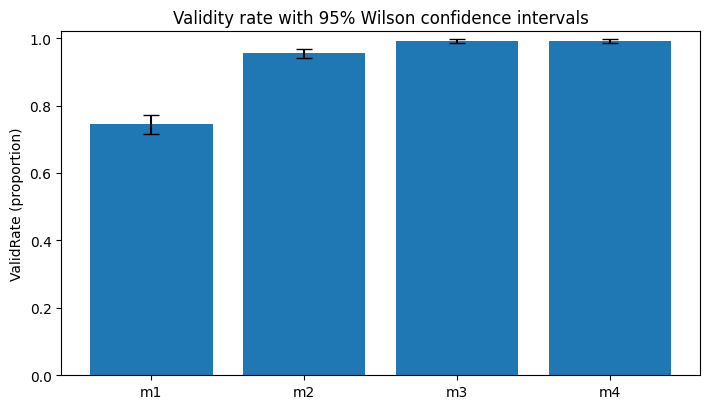

In [81]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k/n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z*np.sqrt((p*(1-p)/n) + (z*z/(4*n*n)))) / denom
    return center-half, center+half

vals, lo, hi = [], [], []
n = len(df_clean)

for m in methods:
    col = valid_cols[m]
    if col is None:
        raise ValueError(f"Could not find validity column for {m}. Look for columns like m1_valid, m2_valid, etc.")
    k = int(df_clean[col].sum())
    p = k/n
    a,b = wilson_ci(k,n)
    vals.append(p); lo.append(p-a); hi.append(b-p)

plt.figure(figsize=(7.2,4.2))
x = np.arange(len(methods))
plt.bar(x, vals, yerr=[lo,hi], capsize=6)
plt.xticks(x, methods)
plt.ylim(0, 1.02)
plt.ylabel("ValidRate (proportion)")
plt.title("Validity rate with 95% Wilson confidence intervals")
plt.tight_layout()
plt.savefig("fig_validrate_wilson.png", dpi=300)
plt.savefig("fig_validrate_wilson.pdf")
plt.show()

In [82]:
import numpy as np
import matplotlib.pyplot as plt

rqi_cols = {m: find_col(df_clean, m, ["rqi2","rqi"]) for m in methods}
rqi_cols

{'m1': 'm1_rqi2', 'm2': 'm2_rqi2', 'm3': 'm3_rqi2', 'm4': 'm4_rqi2'}

C:\Users\doruk\AppData\Local\Temp\ipykernel_41676\3567417355.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


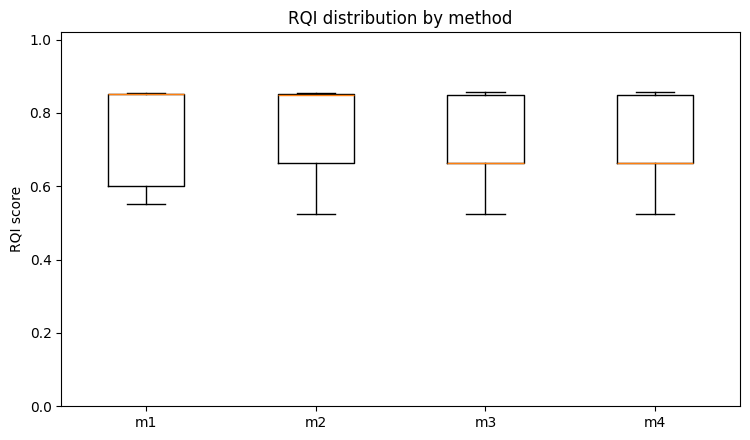

In [83]:
data = []
labels = []
for m in methods:
    col = rqi_cols[m]
    if col is None:
        raise ValueError(f"Could not find RQI column for {m}. Expected m*_rqi2 or m*_rqi.")
    x = df_clean[col].astype(float).values
    x = x[np.isfinite(x)]
    data.append(x)
    labels.append(m)

plt.figure(figsize=(7.6,4.5))
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylim(0, 1.02)
plt.ylabel("RQI score")
plt.title("RQI distribution by method")
plt.tight_layout()
plt.savefig("fig_rqi_boxplot.png", dpi=300)
plt.savefig("fig_rqi_boxplot.pdf")
plt.show()

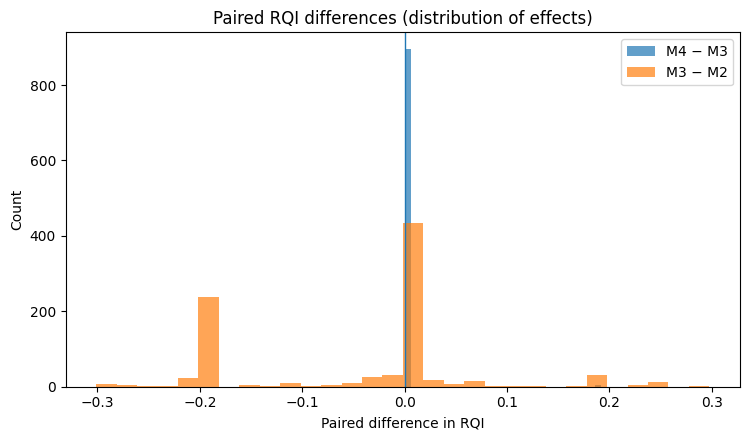

In [84]:
import numpy as np
import matplotlib.pyplot as plt

m2 = df_clean[rqi_cols["m2"]].astype(float).values
m3 = df_clean[rqi_cols["m3"]].astype(float).values
m4 = df_clean[rqi_cols["m4"]].astype(float).values

d_43 = m4 - m3
d_32 = m3 - m2

d_43 = d_43[np.isfinite(d_43)]
d_32 = d_32[np.isfinite(d_32)]

plt.figure(figsize=(7.6,4.5))
plt.hist(d_43, bins=30, alpha=0.7, label="M4 − M3")
plt.hist(d_32, bins=30, alpha=0.7, label="M3 − M2")
plt.axvline(0, linewidth=1)
plt.xlabel("Paired difference in RQI")
plt.ylabel("Count")
plt.title("Paired RQI differences (distribution of effects)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_rqi_paired_diffs.png", dpi=300)
plt.savefig("fig_rqi_paired_diffs.pdf")
plt.show()

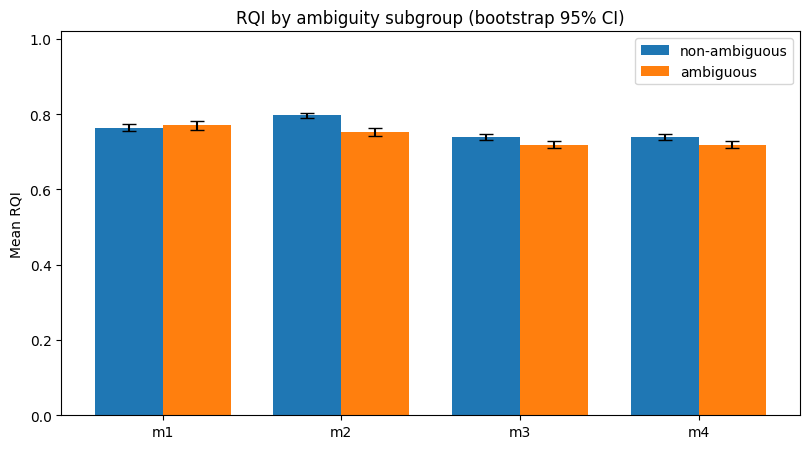

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Try common ambiguity label columns
label_col = None
for c in ["label", "HasAmbiguity", "has_ambiguity", "ambiguous"]:
    if c in df_clean.columns:
        label_col = c
        break
if label_col is None:
    raise ValueError("Could not find ambiguity label column (e.g., 'label' or 'HasAmbiguity').")

def bootstrap_mean_ci(x, iters=4000, seed=0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    rng = np.random.default_rng(seed)
    if len(x) == 0:
        return np.nan, (np.nan, np.nan)
    means = rng.choice(x, size=(iters, len(x)), replace=True).mean(axis=1)
    return float(x.mean()), (float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5)))

groups = {"non-ambiguous": df_clean[df_clean[label_col].astype(int)==0],
          "ambiguous":     df_clean[df_clean[label_col].astype(int)==1]}

means = {g: [] for g in groups}
cis   = {g: [] for g in groups}

for g, dfg in groups.items():
    for m in methods:
        col = rqi_cols[m]
        mu, (a,b) = bootstrap_mean_ci(dfg[col].values, seed=hash(g+m) % 1000)
        means[g].append(mu)
        cis[g].append((a,b))

x = np.arange(len(methods))
w = 0.38

plt.figure(figsize=(8.2,4.6))
for i,(g,vals) in enumerate(means.items()):
    y = np.array(vals)
    yerr = np.array([[y[j]-cis[g][j][0] for j in range(len(y))],
                     [cis[g][j][1]-y[j] for j in range(len(y))]])
    plt.bar(x + (i-0.5)*w, y, width=w, yerr=yerr, capsize=5, label=g)

plt.xticks(x, methods)
plt.ylim(0,1.02)
plt.ylabel("Mean RQI")
plt.title("RQI by ambiguity subgroup (bootstrap 95% CI)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_rqi_subgroup.png", dpi=300)
plt.savefig("fig_rqi_subgroup.pdf")
plt.show()

In [86]:
import os, json
from openai import OpenAI

oa = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
# Reproducibility for a paper: lock snapshot
VALIDATOR_MODEL = "gpt-5.2-2025-12-11"  # snapshot listed in docs :contentReference[oaicite:1]{index=1}


In [87]:
REQ_EVAL_SCHEMA = {
    "name": "requirement_quality_eval",
    "description": "Rubric-based quality evaluation of a rewritten software requirement vs original.",
    "schema": {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "starts_with_shall": {"type": "boolean"},
            "single_sentence": {"type": "boolean"},
            "word_count": {"type": "integer", "minimum": 0},
            "within_word_range": {"type": "boolean"},

            "atomicity": {"type": "integer", "minimum": 1, "maximum": 5},
            "testability": {"type": "integer", "minimum": 1, "maximum": 5},
            "unambiguity": {"type": "integer", "minimum": 1, "maximum": 5},
            "conciseness": {"type": "integer", "minimum": 1, "maximum": 5},
            "faithfulness": {"type": "integer", "minimum": 1, "maximum": 5},

            "overall_0to1": {"type": "number", "minimum": 0.0, "maximum": 1.0},

            "defects": {
                "type": "array",
                "items": {"type": "string"},
                "maxItems": 6
            },
            "short_rationale": {"type": "string"}
        },
        "required": [
            "starts_with_shall","single_sentence","word_count","within_word_range",
            "atomicity","testability","unambiguity","conciseness","faithfulness",
            "overall_0to1","defects","short_rationale"
        ]
    },
    "strict": True
}

def gpt52_validate(original: str, candidate: str, min_words=12, max_words=30) -> dict:
    system = (
        "You are a strict requirements-quality validator. "
        "Score the CANDIDATE requirement against the ORIGINAL intent.\n"
        "Use this 1–5 rubric per dimension:\n"
        "Atomicity: 1=multiple independent requirements, 5=single atomic.\n"
        "Testability: 1=not verifiable, 5=verifiable with measurable criteria.\n"
        "Unambiguity: 1=vague/subjective/weak modals, 5=precise.\n"
        "Conciseness: 1=rambling/redundant, 5=brief without losing constraints.\n"
        "Faithfulness: 1=adds/drops constraints, 5=preserves intent/constraints.\n"
        "Return JSON only."
    )

    user = f"""ORIGINAL:
{original}

CANDIDATE:
{candidate}

Hard constraints to check:
- Must be exactly one sentence.
- Must start exactly with: "The system shall"
- Must be {min_words}–{max_words} words.

Compute:
- word_count using token-like words
- within_word_range based on {min_words}–{max_words}
- starts_with_shall exactly
- single_sentence (no multiple independent sentences)

Set overall_0to1 = (atomicity+testability+unambiguity+conciseness+faithfulness)/25.

Include up to 6 defects (short phrases).
short_rationale: <= 2 sentences.
"""

    resp = oa.chat.completions.create(
        model=VALIDATOR_MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
        temperature=0.0,
        response_format={"type": "json_schema", "json_schema": REQ_EVAL_SCHEMA},  # Structured Outputs :contentReference[oaicite:2]{index=2}
        max_completion_tokens=350,
    )
    return json.loads(resp.choices[0].message.content)

In [88]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def thread_map(func, items, max_workers=10, desc=""):
    out = [None] * len(items)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(func, items[i]): i for i in range(len(items))}
        for fut in tqdm(as_completed(futs), total=len(items), desc=desc):
            i = futs[fut]
            try:
                out[i] = fut.result()
            except Exception as e:
                out[i] = {"error": str(e)}
    return out

In [89]:
print(df_final_results.head())

    uid                                               text  label
0  3716  As a nurse, I want to access records in order ...   True
1  4675  As a customer, I would like to search products...  False
2  7038  As a subscriber, I want to process requests in...   True
3  1262  As a bank customer, I need to view account bal...  False
4  1657  As a account holder, I would like to download ...  False


In [90]:
MIN_WORDS, MAX_WORDS = 12, 30
MAX_WORKERS = 10   # 8–16 is typical. If you hit rate limits, lower it.
AUDIT_N = 500

# 1. Sample directly from df_clean (which has all your model outputs!)
df_audit = df_clean.sample(AUDIT_N, random_state=42).copy()

def mk_item(row, method):
    return (row["text"], row[f"{method}_output"])

for m in ["m2", "m3", "m4"]:
    # 2. Iterate over the new 500-row sample
    items = [mk_item(r, m) for _, r in df_audit.iterrows()]
    
    # 3. Save the GPT validation scores back to the sample
    df_audit[f"{m}_llm_val"] = thread_map(
        lambda pair: gpt52_validate(pair[0], pair[1], MIN_WORDS, MAX_WORDS),
        items,
        max_workers=MAX_WORKERS,
        desc=f"GPT5.2 validate {m}"
    )

GPT5.2 validate m4: 100%|██████████| 500/500 [02:30<00:00,  3.33it/s]


In [91]:
print(type(df_audit["m3_llm_val"].iloc[0]))

<class 'dict'>


In [92]:
print(df_audit["m3_llm_val"].iloc[0])

{'starts_with_shall': True, 'single_sentence': True, 'word_count': 12, 'within_word_range': True, 'atomicity': 3, 'testability': 3, 'unambiguity': 3, 'conciseness': 4, 'faithfulness': 2, 'overall_0to1': 0.6, 'defects': ['Shifts intent from vendor leaving a review to system recording reviews', 'Does not address vendor goal to track delivery', 'Vague terms: "detailed" and "comprehensive" not defined', 'Unclear what constitutes "requirement data"'], 'short_rationale': 'Meets the hard formatting constraints and is concise, but it changes the user action/goal into a generic recording function. Key intent about enabling delivery tracking via reviews is not explicitly preserved and several terms remain vague.'}


In [93]:
import numpy as np
import pandas as pd

def unpack_val(d, key, default=np.nan):
    return d.get(key, default) if isinstance(d, dict) else default

for m in ["m2","m3","m4"]:
    dcol = f"{m}_llm_val"

    df_audit[f"{m}_llm_overall"]   = df_audit[dcol].apply(lambda d: unpack_val(d, "overall_0to1"))
    df_audit[f"{m}_llm_atomicity"] = df_audit[dcol].apply(lambda d: unpack_val(d, "atomicity"))
    df_audit[f"{m}_llm_testability"]= df_audit[dcol].apply(lambda d: unpack_val(d, "testability"))
    df_audit[f"{m}_llm_unamb"]     = df_audit[dcol].apply(lambda d: unpack_val(d, "unambiguity"))
    df_audit[f"{m}_llm_concise"]   = df_audit[dcol].apply(lambda d: unpack_val(d, "conciseness"))
    df_audit[f"{m}_llm_faith"]     = df_audit[dcol].apply(lambda d: unpack_val(d, "faithfulness"))

rows=[]
for m,label in [("m2","M2"),("m3","M3"),("m4","M4")]:
    rows.append({
        "Method": label,
        "GPT5.2 Overall ↑": df_audit[f"{m}_llm_overall"].mean(),
        "Atomicity ↑": df_audit[f"{m}_llm_atomicity"].mean(),
        "Testability ↑": df_audit[f"{m}_llm_testability"].mean(),
        "Unambiguity ↑": df_audit[f"{m}_llm_unamb"].mean(),
        "Conciseness ↑": df_audit[f"{m}_llm_concise"].mean(),
        "Faithfulness ↑": df_audit[f"{m}_llm_faith"].mean(),
    })

df_llm_summary = pd.DataFrame(rows).round(4)
print(df_llm_summary.to_string(index=False))

Method  GPT5.2 Overall ↑  Atomicity ↑  Testability ↑  Unambiguity ↑  Conciseness ↑  Faithfulness ↑
    M2            0.7307        3.826          3.184          3.184          4.832           3.242
    M3            0.6679        3.120          3.246          3.174          4.534           2.624
    M4            0.6702        3.138          3.260          3.168          4.548           2.642


In [94]:
import scipy.stats as st

for m in ["m2","m3","m4"]:
    rho = st.spearmanr(df_audit[f"{m}_rqi2"], df_audit[f"{m}_llm_overall"], nan_policy="omit").correlation
    print(f"Spearman(RQI₂, GPT5.2 overall) {m}: {rho:.3f}")

Spearman(RQI₂, GPT5.2 overall) m2: 0.372
Spearman(RQI₂, GPT5.2 overall) m3: 0.368
Spearman(RQI₂, GPT5.2 overall) m4: 0.384


In [95]:
(df_audit["m4_output"].astype(str) != df_audit["m3_output"].astype(str)).mean()

np.float64(0.016)

In [96]:
changed = (df_audit["m4_output"].astype(str) != df_audit["m2_output"].astype(str))

# If you already have these columns:
# m2_rqi2, m4_rqi2, m2_llm_overall, m4_llm_overall

df_audit["delta_rqi2"] = df_audit["m4_rqi2"] - df_audit["m2_rqi2"]
df_audit["delta_gpt"]  = df_audit["m4_llm_overall"] - df_audit["m2_llm_overall"]

print("Change rate:", changed.mean())
print("ΔRQI₂ mean (all):", df_audit["delta_rqi2"].mean())
print("ΔRQI₂ mean (changed only):", df_audit.loc[changed, "delta_rqi2"].mean())
print("ΔGPT mean (changed only):", df_audit.loc[changed, "delta_gpt"].mean())

# how often repair helps vs hurts (GPT)
print("GPT help rate on changed:", (df_audit.loc[changed, "delta_gpt"] > 0).mean())
print("GPT hurt rate on changed:", (df_audit.loc[changed, "delta_gpt"] < 0).mean())


Change rate: 0.982
ΔRQI₂ mean (all): -0.04830335507707095
ΔRQI₂ mean (changed only): -0.0491887526243085
ΔGPT mean (changed only): -0.061588594704684314
GPT help rate on changed: 0.20773930753564154
GPT hurt rate on changed: 0.6293279022403259


In [97]:
[a for a in df_audit.columns if "llm_" in a][:30], df_audit[[c for c in df_audit.columns if c.endswith("_llm_overall")]].head()


(['m2_llm_val',
  'm3_llm_val',
  'm4_llm_val',
  'm2_llm_overall',
  'm2_llm_atomicity',
  'm2_llm_testability',
  'm2_llm_unamb',
  'm2_llm_concise',
  'm2_llm_faith',
  'm3_llm_overall',
  'm3_llm_atomicity',
  'm3_llm_testability',
  'm3_llm_unamb',
  'm3_llm_concise',
  'm3_llm_faith',
  'm4_llm_overall',
  'm4_llm_atomicity',
  'm4_llm_testability',
  'm4_llm_unamb',
  'm4_llm_concise',
  'm4_llm_faith'],
      m2_llm_overall  m3_llm_overall  m4_llm_overall
 70             0.76            0.60            0.64
 827            0.76            0.68            0.72
 231            0.72            0.48            0.52
 588            0.56            0.48            0.52
 39             0.88            0.68            0.64)

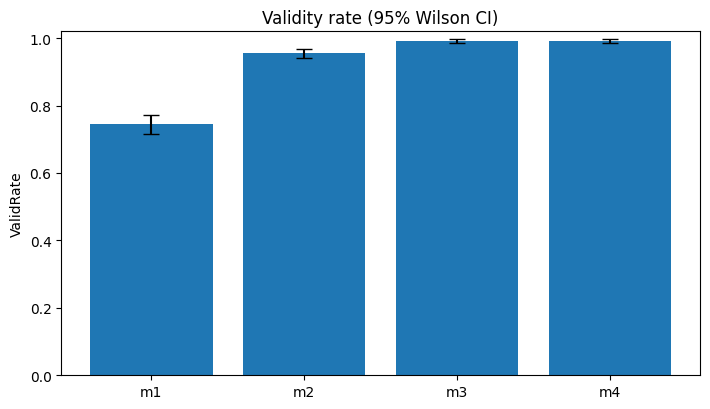

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k/n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z*np.sqrt((p*(1-p)/n) + (z*z/(4*n*n)))) / denom
    return center-half, center+half

methods = ["m1","m2","m3","m4"]
n = len(df_clean)

vals, lo, hi = [], [], []
for m in methods:
    col = f"{m}_valid"
    k = int(df_clean[col].sum())
    p = k/n
    a,b = wilson_ci(k,n)
    vals.append(p); lo.append(p-a); hi.append(b-p)

x = np.arange(len(methods))
plt.figure(figsize=(7.2,4.2))
plt.bar(x, vals, yerr=[lo,hi], capsize=6)
plt.xticks(x, methods)
plt.ylim(0, 1.02)
plt.ylabel("ValidRate")
plt.title("Validity rate (95% Wilson CI)")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig_validrate_wilson.png", dpi=300)
plt.savefig(f"{OUTDIR}/fig_validrate_wilson.pdf")
plt.show()

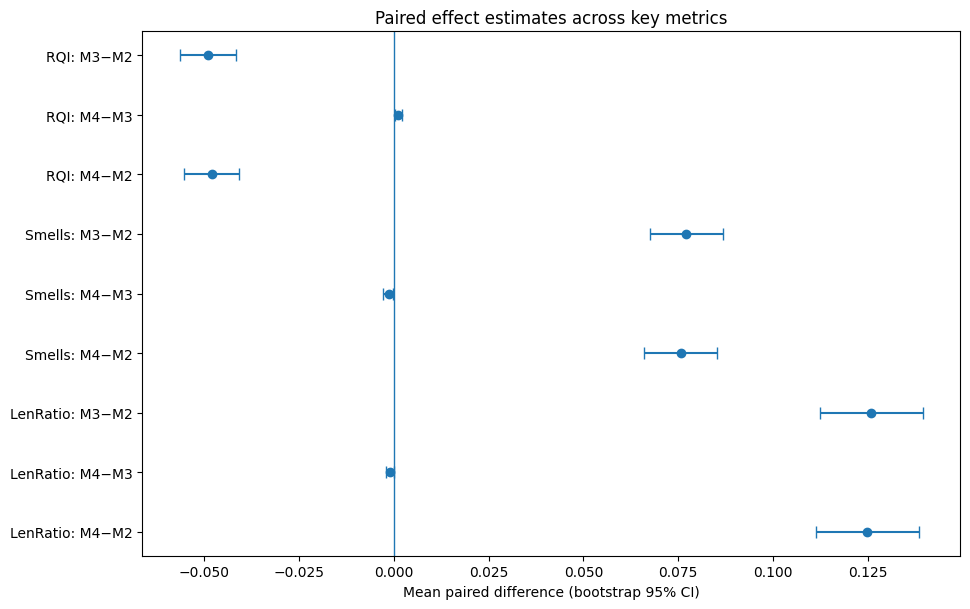

In [99]:
import numpy as np
import matplotlib.pyplot as plt

def bootstrap_ci(diff, iters=5000, seed=42):
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    if len(diff) == 0: return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(diff, size=(iters, len(diff)), replace=True).mean(axis=1)
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

comparisons = [
    ("RQI: M3−M2", "m3_rqi2", "m2_rqi2"),
    ("RQI: M4−M3", "m4_rqi2", "m3_rqi2"),
    ("RQI: M4−M2", "m4_rqi2", "m2_rqi2"),

    ("Smells: M3−M2", "m3_S", "m2_S"),
    ("Smells: M4−M3", "m4_S", "m3_S"),
    ("Smells: M4−M2", "m4_S", "m2_S"),

    ("LenRatio: M3−M2", "m3_len_ratio", "m2_len_ratio"),
    ("LenRatio: M4−M3", "m4_len_ratio", "m3_len_ratio"),
    ("LenRatio: M4−M2", "m4_len_ratio", "m2_len_ratio"),

    ("Faith: M3−M2", "m3_faith", "m2_faith") if "m3_faith" in df_clean.columns else None,
    ("Faith: M4−M3", "m4_faith", "m3_faith") if "m4_faith" in df_clean.columns and "m3_faith" in df_clean.columns else None,
    ("Faith: M4−M2", "m4_faith", "m2_faith") if "m4_faith" in df_clean.columns else None,
]
comparisons = [c for c in comparisons if c is not None]

rows = []
for name, a, b in comparisons:
    diff = df_clean[a].astype(float).values - df_clean[b].astype(float).values
    mu = float(np.nanmean(diff))
    lo, hi = bootstrap_ci(diff, seed=abs(hash(name)) % 10_000)
    rows.append((name, mu, lo, hi))

labels = [r[0] for r in rows]
mu = np.array([r[1] for r in rows])
lo = np.array([r[1]-r[2] for r in rows])
hi = np.array([r[3]-r[1] for r in rows])

y = np.arange(len(rows))[::-1]
plt.figure(figsize=(9.8, 6.2))
plt.errorbar(mu, y, xerr=[lo, hi], fmt='o', capsize=4)
plt.axvline(0, linewidth=1)
plt.yticks(y, labels)
plt.xlabel("Mean paired difference (bootstrap 95% CI)")
plt.title("Paired effect estimates across key metrics")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig_forest_effects.png", dpi=300)
plt.savefig(f"{OUTDIR}/fig_forest_effects.pdf")
plt.show()

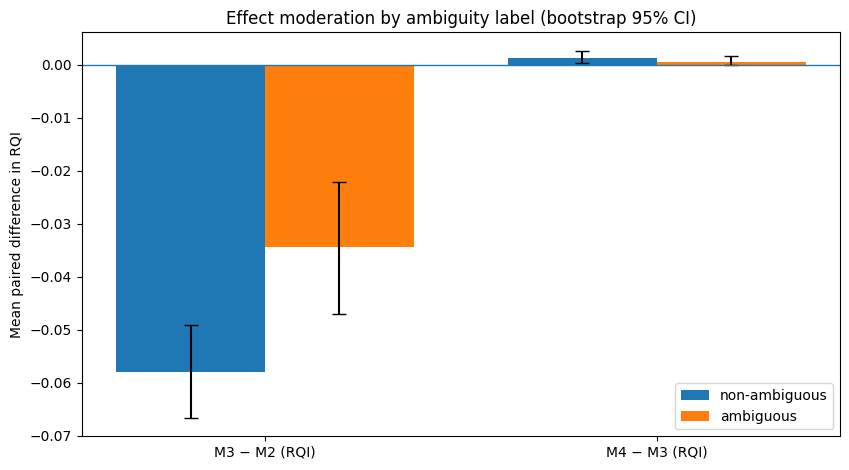

In [100]:
import numpy as np
import matplotlib.pyplot as plt

def bootstrap_mean_ci(x, iters=5000, seed=0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0: return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(iters, len(x)), replace=True).mean(axis=1)
    mu = float(x.mean())
    lo = float(np.percentile(means, 2.5))
    hi = float(np.percentile(means, 97.5))
    return mu, lo, hi

groups = {
    "non-ambiguous": df_clean[df_clean["label"].astype(int) == 0],
    "ambiguous": df_clean[df_clean["label"].astype(int) == 1],
}

effects = [
    ("M3 − M2 (RQI)", "m3_rqi2", "m2_rqi2"),
    ("M4 − M3 (RQI)", "m4_rqi2", "m3_rqi2"),
]

x = np.arange(len(effects))
w = 0.38

plt.figure(figsize=(8.6,4.8))
for gi,(gname, dfg) in enumerate(groups.items()):
    mus, ylo, yhi = [], [], []
    for name, a, b in effects:
        diff = dfg[a].astype(float).values - dfg[b].astype(float).values
        mu, lo, hi = bootstrap_mean_ci(diff, seed=abs(hash(gname+name)) % 10_000)
        mus.append(mu); ylo.append(mu-lo); yhi.append(hi-mu)
    plt.bar(x + (gi-0.5)*w, mus, width=w, yerr=[ylo,yhi], capsize=5, label=gname)

plt.axhline(0, linewidth=1)
plt.xticks(x, [e[0] for e in effects])
plt.ylabel("Mean paired difference in RQI")
plt.title("Effect moderation by ambiguity label (bootstrap 95% CI)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig_ambiguity_moderation.png", dpi=300)
plt.savefig(f"{OUTDIR}/fig_ambiguity_moderation.pdf")
plt.show()

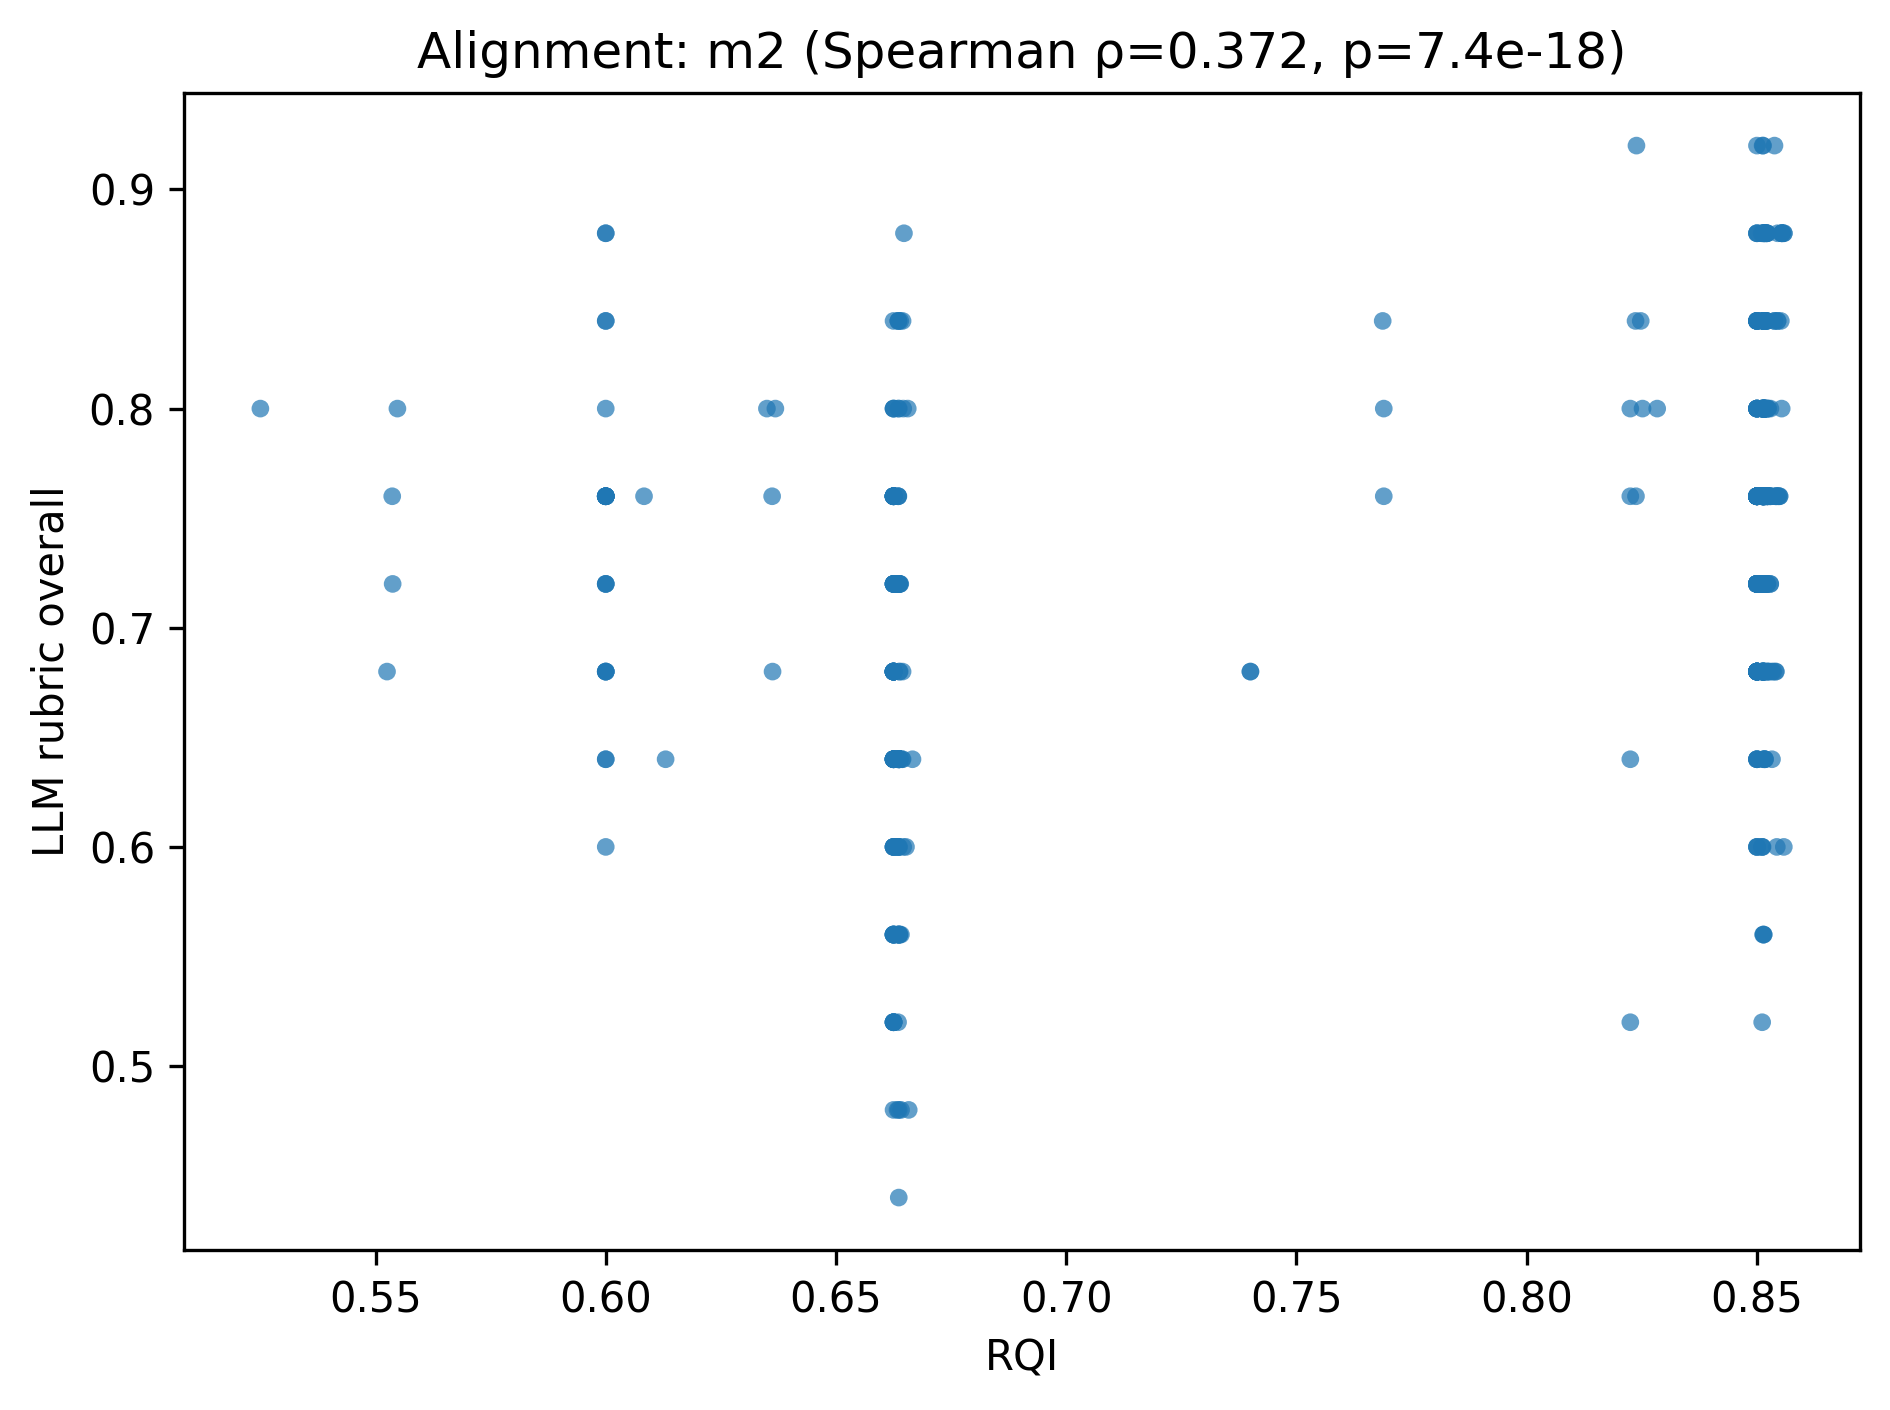

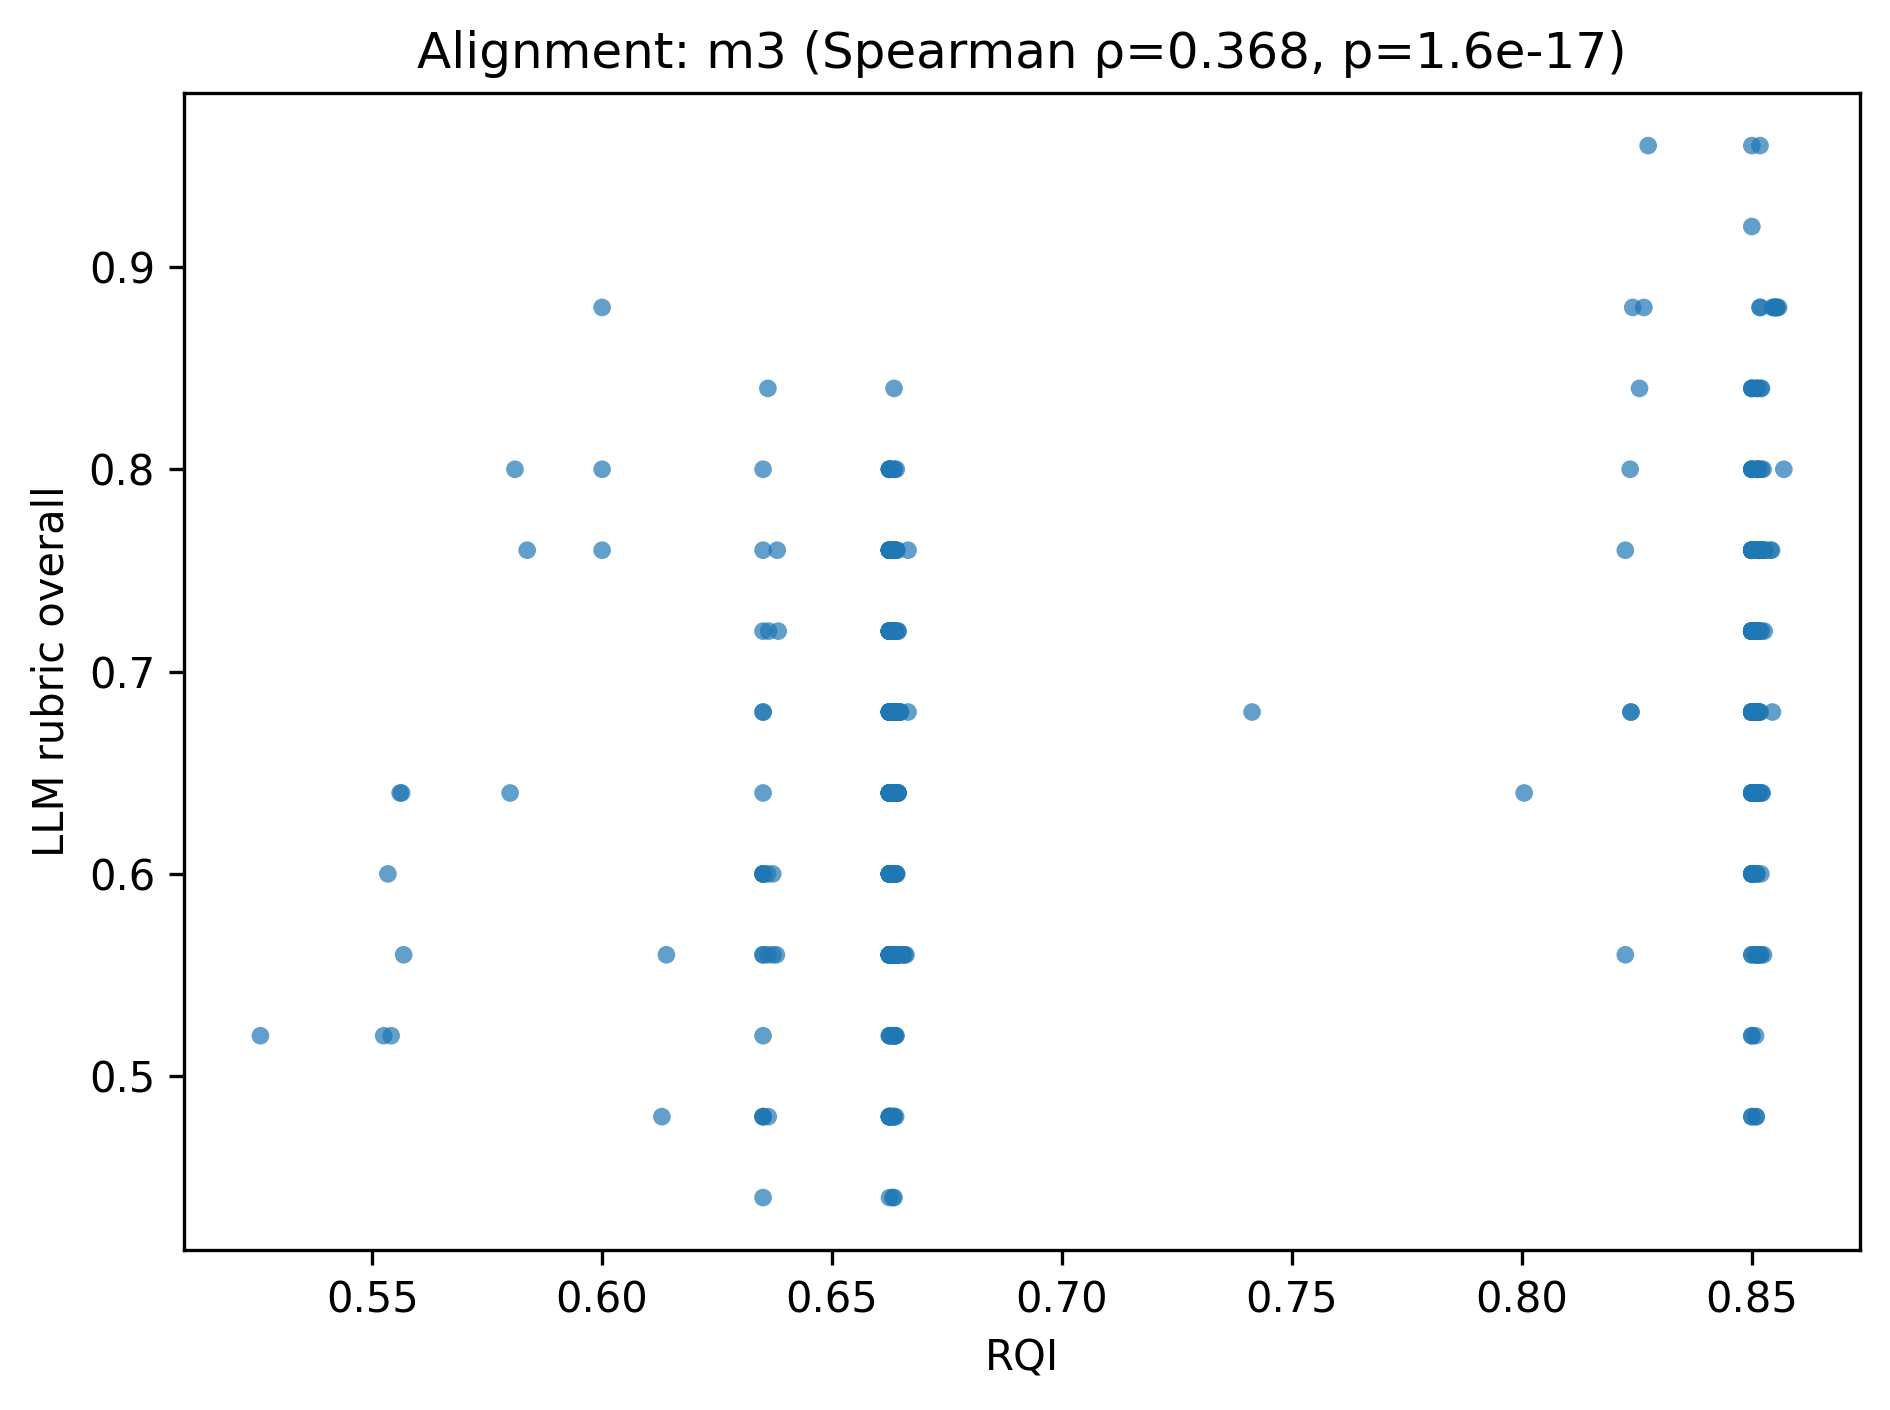

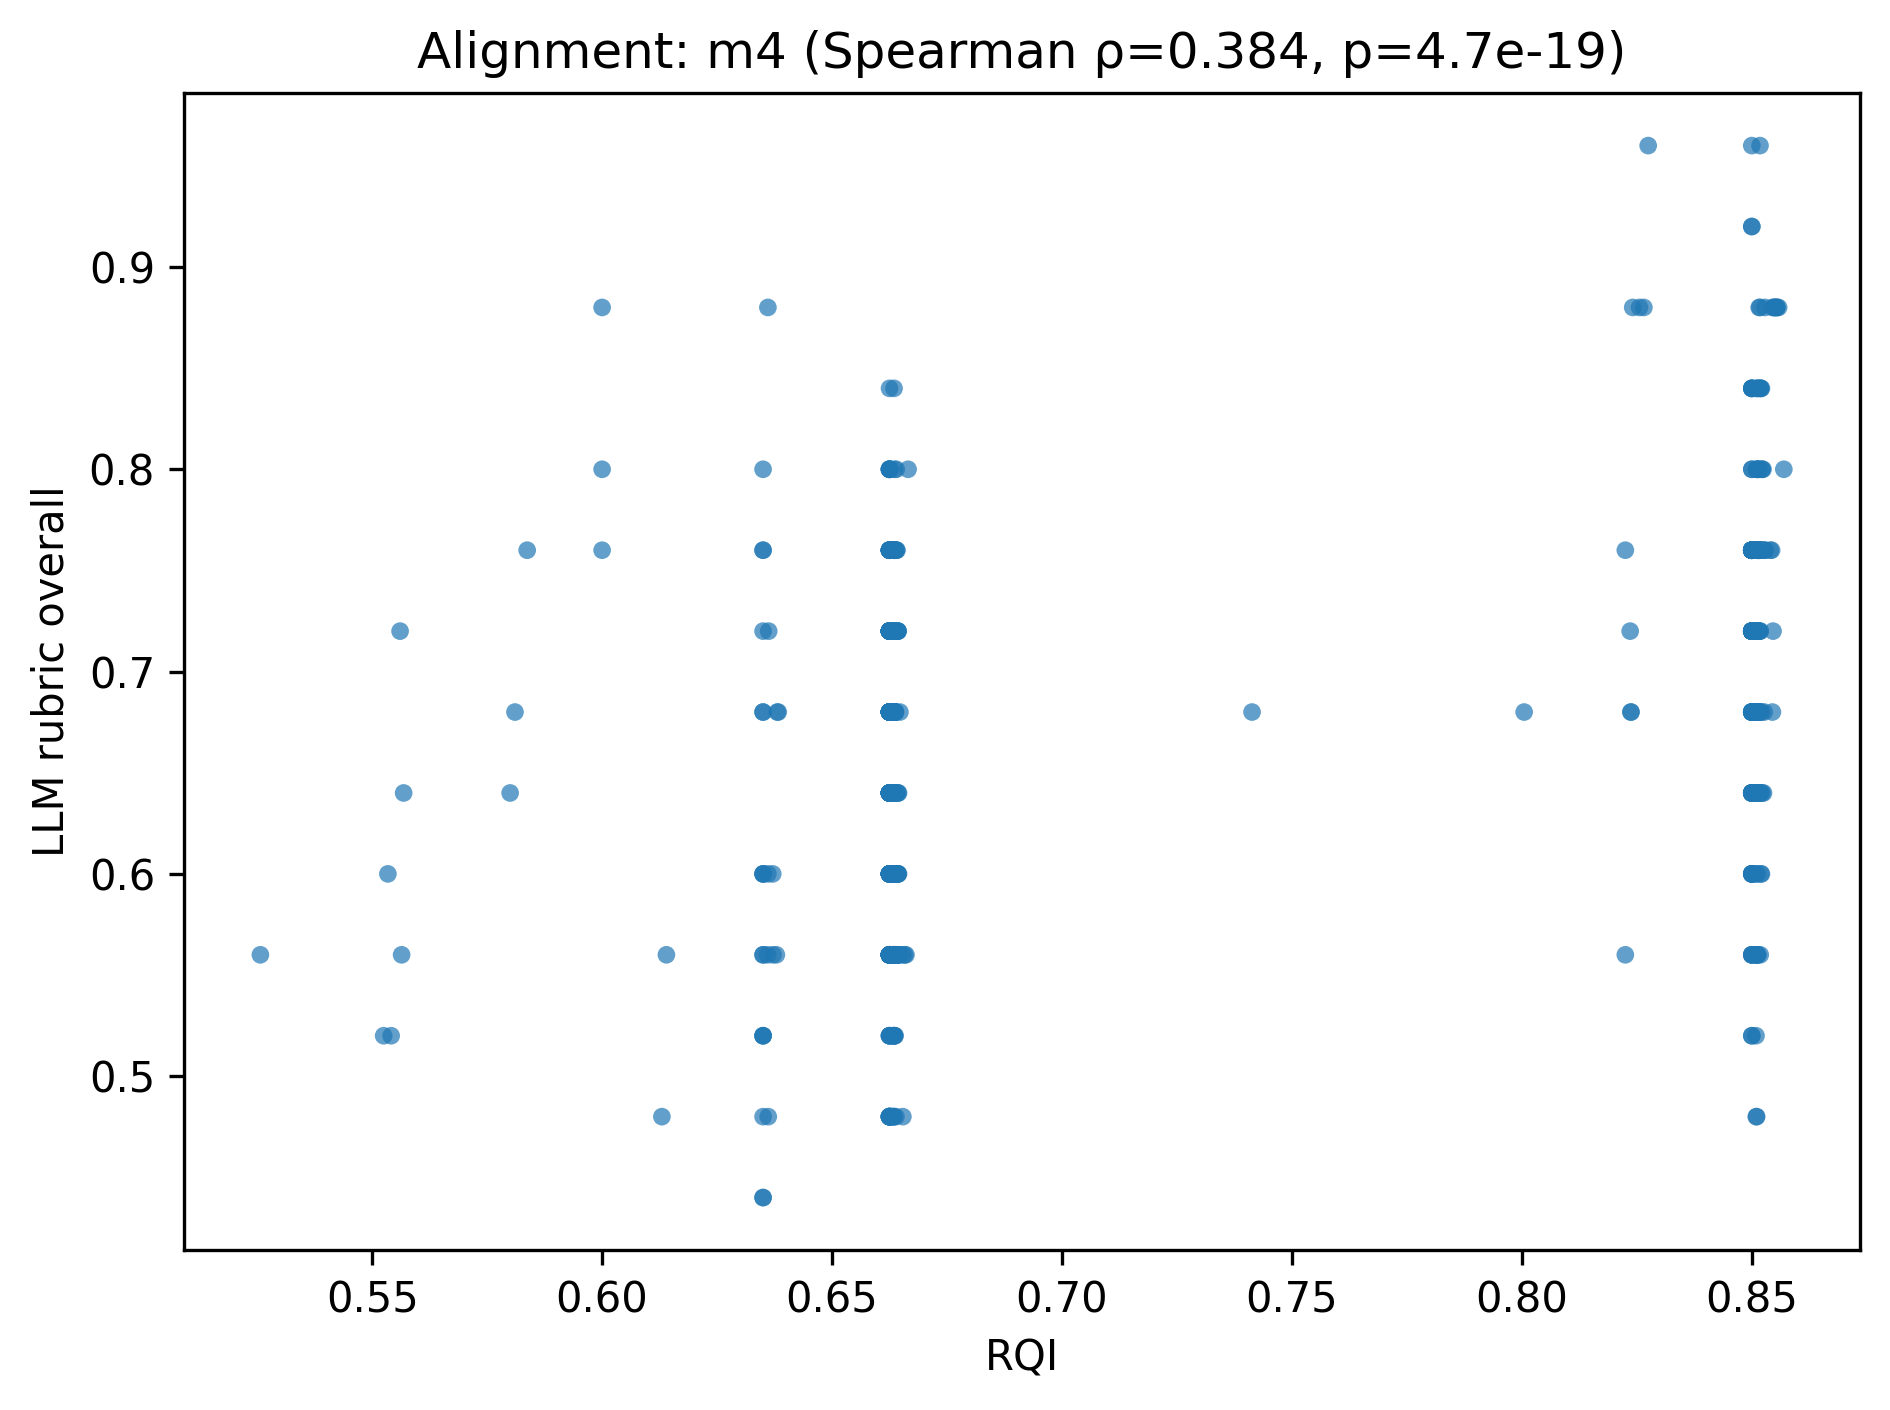

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_align(m):
    xcol = f"{m}_rqi2"
    ycol = f"{m}_llm_overall"
    tmp = df_audit[[xcol, ycol]].astype(float).dropna()
    rho, p = spearmanr(tmp[xcol], tmp[ycol])

    plt.figure(figsize=(6.4,4.8), dpi=300, tight_layout=True, facecolor='white', edgecolor='white', linewidth=0)
    plt.scatter(tmp[xcol], tmp[ycol], s=18, alpha=0.7, edgecolors='none', color='tab:blue')
    plt.xlabel("RQI")
    plt.ylabel("LLM rubric overall")
    plt.title(f"Alignment: {m} (Spearman ρ={rho:.3f}, p={p:.1e})")
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/fig_align_{m}.png", dpi=300)
    plt.savefig(f"{OUTDIR}/fig_align_{m}.pdf")
    plt.show()

for m in ["m2","m3","m4"]:
    plot_align(m)

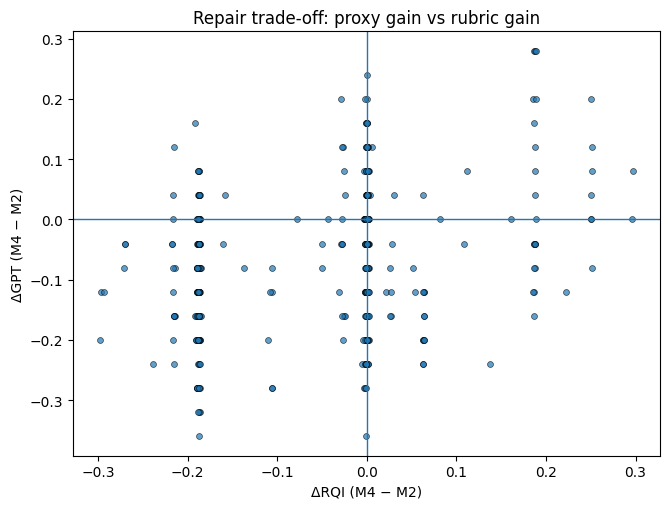

Quadrant rates on changed cases:
++ (better in both): 0.0835030549898167
+- (better RQI, worse GPT): 0.1425661914460285
-+ (worse RQI, better GPT): 0.08961303462321792
-- (worse in both): 0.4439918533604888


In [102]:
import numpy as np
import matplotlib.pyplot as plt

tmp = df_audit[["delta_rqi2", "delta_gpt", "m2_output", "m4_output"]].copy()
tmp["changed"] = (tmp["m4_output"].astype(str) != tmp["m2_output"].astype(str))
tmp = tmp[tmp["changed"]].dropna(subset=["delta_rqi2","delta_gpt"])

plt.figure(figsize=(6.8,5.2))
plt.scatter(tmp["delta_rqi2"], tmp["delta_gpt"], s=18, alpha=0.7, edgecolor='k', linewidth=0.5, color='C0')
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("ΔRQI (M4 − M2)")
plt.ylabel("ΔGPT (M4 − M2)")
plt.title("Repair trade-off: proxy gain vs rubric gain")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig_tradeoff_quadrants.png", dpi=300)
plt.savefig(f"{OUTDIR}/fig_tradeoff_quadrants.pdf")
plt.show()

print("Quadrant rates on changed cases:")
print("++ (better in both):", ((tmp["delta_rqi2"]>0) & (tmp["delta_gpt"]>0)).mean())
print("+- (better RQI, worse GPT):", ((tmp["delta_rqi2"]>0) & (tmp["delta_gpt"]<0)).mean())
print("-+ (worse RQI, better GPT):", ((tmp["delta_rqi2"]<0) & (tmp["delta_gpt"]>0)).mean())
print("-- (worse in both):", ((tmp["delta_rqi2"]<0) & (tmp["delta_gpt"]<0)).mean())

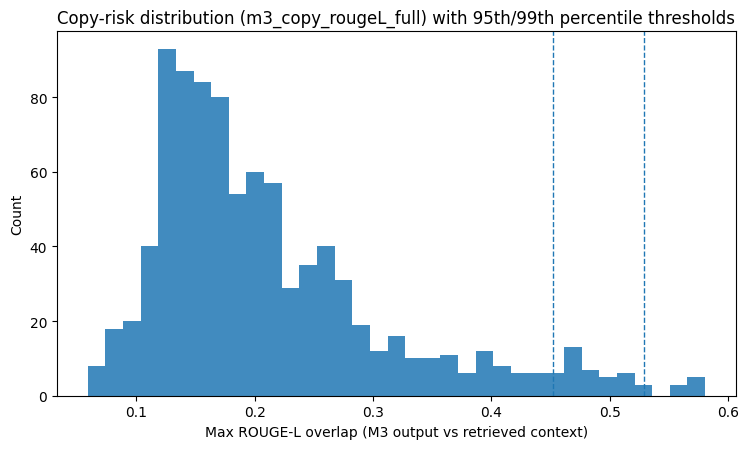

p95: 0.45188940092165875 p99: 0.5294509803921569


In [103]:
import numpy as np
import matplotlib.pyplot as plt

col = "m3_copy_rougeL_full" if "m3_copy_rougeL_full" in df_clean.columns else "m3_copy_rougeL"
x = df_clean[col].astype(float).dropna().values

p95, p99 = np.quantile(x, 0.95), np.quantile(x, 0.99)

plt.figure(figsize=(7.6,4.6))
plt.hist(x, bins=35, alpha=0.85)
plt.axvline(p95, linestyle="--", linewidth=1)
plt.axvline(p99, linestyle="--", linewidth=1)
plt.xlabel("Max ROUGE-L overlap (M3 output vs retrieved context)")
plt.ylabel("Count")
plt.title(f"Copy-risk distribution ({col}) with 95th/99th percentile thresholds")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig_copyrisk_hist.png", dpi=300)
plt.savefig(f"{OUTDIR}/fig_copyrisk_hist.pdf")
plt.show()

print("p95:", p95, "p99:", p99)

In [104]:
import os
import pandas as pd
import numpy as np

QURE_CSV = "QuRE.csv"  # put in same folder as notebook, or replace with full path

assert os.path.exists(QURE_CSV), f"QuRE.csv not found at: {QURE_CSV}"

df_qure_raw = pd.read_csv(QURE_CSV)
expected = {"id", "requirement", "defect", "weak_word"}
missing = expected - set(df_qure_raw.columns)
assert not missing, f"QuRE missing columns: {missing}. Found: {list(df_qure_raw.columns)}"

# Normalize into your experiment schema
df_qure = df_qure_raw.rename(columns={"requirement": "text"}).copy()
df_qure["text"] = df_qure["text"].astype(str).str.strip()
df_qure = df_qure[df_qure["text"].str.len() > 0].reset_index(drop=True)

# Binary label (external): defect vs ok
df_qure["label"] = (df_qure["defect"].astype(str).str.lower() == "defect").astype(int)

print("QuRE loaded:", df_qure.shape)
print(df_qure[["defect", "label"]].value_counts().head())
print("weak_word unique:", df_qure["weak_word"].nunique())
df_qure.head(3)

QuRE loaded: (2187, 5)
defect  label
ok      0        1536
defect  1         651
Name: count, dtype: int64
weak_word unique: 23


,id,text,defect,weak_word,label
0,0,A segment is adequately specified by two points.,ok,adequate,0
1,1,In order to ensure that the severity of this t...,ok,adequate,0
2,2,In order to ensure that the severity of this t...,ok,adequate,0


In [105]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

df_experiment = pd.DataFrame({
    "text": cornelius_texts,
    "label": cornelius_labels
})

df_dev, df_test = train_test_split(
    df_experiment,
    test_size=0.20,
    stratify=df_experiment["label"],
    random_state=RANDOM_SEED
)

# Keep an internal dev sample if you still want it (optional)
df_val_internal = df_dev.sample(n=min(200, len(df_dev)), random_state=RANDOM_SEED).reset_index(drop=True)

# External validation set is QuRE
df_val_external = df_qure.copy().reset_index(drop=True)

print("Data split:")
print("  Cornelius dev:", df_dev.shape, "test:", df_test.shape)
print("  Internal val:", df_val_internal.shape)
print("  External val (QuRE):", df_val_external.shape)
print("  Cornelius ambiguity ratio test:", df_test["label"].mean())
print("  QuRE defect ratio:", df_val_external["label"].mean())

Data split:
  Cornelius dev: (10277, 2) test: (2570, 2)
  Internal val: (200, 2)
  External val (QuRE): (2187, 5)
  Cornelius ambiguity ratio test: 0.3369649805447471
  QuRE defect ratio: 0.29766803840877915


In [2]:
import os
from huggingface_hub import InferenceClient

# HARD-CODE (yes, this will live in the notebook file)
HF_TOKEN = os.environ["HF_TOKEN"]

MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507:nscale"  # or whatever you use
client = InferenceClient(model=REPO_ID, token=HF_TOKEN, timeout=60)

NameError: name 'REPO_ID' is not defined

In [ ]:
headers_json = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "Content-Type": "application/json"
}

NameError: name 'HF_TOKEN' is not defined

In [150]:
import time, random, json, requests

HF_LAST_ERR = None
MODEL_ID_PICKED = "Qwen/Qwen3-4B-Instruct-2507"
PROVIDER_PICKED = "nscale"
ROUTER_MODEL = f"{MODEL_ID_PICKED}:{PROVIDER_PICKED}"
print("ROUTER_MODEL =", ROUTER_MODEL)
def hf_safe_chat(messages, max_tokens=240, temperature=0.0, retries=6, base_sleep=2.0):
    global HF_LAST_ERR
    HF_LAST_ERR = None

    mt = int(max_tokens)
    for a in range(retries):
        payload = {
            "model": ROUTER_MODEL,     # <- critical
            "messages": messages,
            "max_tokens": mt,
            "temperature": float(temperature),
            "stream": False
        }
        try:
            r = requests.post(
                "https://router.huggingface.co/v1/chat/completions",
                headers=headers_json,
                data=json.dumps(payload),
                timeout=180
            )
            if r.status_code == 200:
                return r.json()["choices"][0]["message"]["content"].strip()

            HF_LAST_ERR = f"HTTP {r.status_code}: {r.text[:500]}"

            # retry only transient
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(min(30, base_sleep*(2**a) + random.random()))
                mt = max(80, int(mt * 0.85))
                continue

            return None

        except Exception as e:
            HF_LAST_ERR = repr(e)
            time.sleep(min(30, base_sleep*(2**a) + random.random()))
            mt = max(80, int(mt * 0.85))

    return None

# smoke check
out = hf_safe_chat([{"role":"user","content":"Reply with exactly: OK"}], max_tokens=12)
print("out:", out, "| err:", HF_LAST_ERR)

ROUTER_MODEL = Qwen/Qwen3-4B-Instruct-2507:nscale
out: OK | err: None


In [146]:
import pandas as pd
import numpy as np

# Load if not already
if "df_val_external" not in globals():
    df_q = pd.read_csv("QuRE.csv")
    df_val_external = df_q.copy()

# Ensure required columns
if "text" not in df_val_external.columns:
    if "requirement" in df_val_external.columns:
        df_val_external["text"] = df_val_external["requirement"].astype(str)
    else:
        raise KeyError("QuRE df missing both 'text' and 'requirement' columns")

# Binary label for stratification (external only, doesn’t affect rewriting)
# You can also set label = 1 for defect, 0 for ok
if "label" not in df_val_external.columns:
    if "defect" in df_val_external.columns:
        df_val_external["label"] = (df_val_external["defect"].astype(str).str.lower() == "defect").astype(int)
    else:
        df_val_external["label"] = 0

# Ensure id exists
if "id" not in df_val_external.columns:
    df_val_external["id"] = np.arange(len(df_val_external), dtype=int)

print("df_val_external cols:", df_val_external.columns.tolist())
print("df_val_external shape:", df_val_external.shape)
print("label rate:", df_val_external["label"].mean())

df_val_external cols: ['id', 'text', 'defect', 'weak_word', 'label']
df_val_external shape: (2187, 5)
label rate: 0.29766803840877915


In [147]:
def stratified_sample(df, n, seed=42, label_col="label"):
    df = df.copy()
    n = int(min(n, len(df)))
    if n <= 0:
        return df.iloc[:0].copy()

    if label_col is None or label_col not in df.columns:
        return df.sample(n=n, random_state=seed)

    vc = df[label_col].value_counts(dropna=False)
    frac = vc / vc.sum()

    parts = []
    for cls, f in frac.items():
        k = int(round(f * n))
        k = max(1, k)
        g = df[df[label_col] == cls]
        parts.append(g.sample(n=min(k, len(g)), random_state=seed))

    out = pd.concat(parts, ignore_index=True)

    # adjust to exact n
    if len(out) > n:
        out = out.sample(n=n, random_state=seed)
    elif len(out) < n:
        need = n - len(out)
        remaining = df.drop(index=out.index, errors="ignore")
        if need > 0 and len(remaining) > 0:
            out = pd.concat([out, remaining.sample(n=min(need, len(remaining)), random_state=seed)], ignore_index=True)

    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

In [148]:
SEEDS = [11, 22, 33]
N_PER_SEED_QURE = 300
BASE_SEED = 2026

n_total = min(len(df_val_external), N_PER_SEED_QURE * len(SEEDS))
pool_q = stratified_sample(df_val_external, n=n_total, seed=BASE_SEED, label_col="label")

pool_q = pool_q.sample(frac=1.0, random_state=BASE_SEED).reset_index(drop=True)

runs_q = []
for i, s in enumerate(SEEDS):
    part = pool_q.iloc[i*N_PER_SEED_QURE:(i+1)*N_PER_SEED_QURE].copy()
    part["seed"] = s
    runs_q.append(part)

df_qure_multi = pd.concat(runs_q, ignore_index=True)

dup = df_qure_multi["id"].duplicated().sum()
print("qure multi shape:", df_qure_multi.shape)
print("duplicate id count:", dup)
assert dup == 0, "QuRE overlap still exists."

qure multi shape: (900, 6)
duplicate id count: 0


In [ ]:
# ===================== QuRE FIX 1: router config + always return text =====================
import os, json, time, random, requests

HF_LAST_ERR = None

# You must set HF_TOKEN in env and restart kernel OR set it here temporarily (don't commit).
HF_TOKEN = os.environ["HF_TOKEN"] 


# Ensure ROUTER_MODEL exists (your notebook defines this in the router cell)
assert "ROUTER_MODEL" in globals(), "ROUTER_MODEL not defined. Run your router hf_safe_chat cell first (the one that prints ROUTER_MODEL)."

def hf_router_chat_text(messages, max_tokens=80, temperature=0.0, retries=6, base_sleep=2.0, timeout=180):
    """
    Returns a STRING or None. Never raises.
    """
    global HF_LAST_ERR
    HF_LAST_ERR = None

    mt = int(max_tokens)
    for a in range(retries):
        payload = {
            "model": ROUTER_MODEL,
            "messages": messages,
            "max_tokens": mt,
            "temperature": float(temperature),
            "stream": False
        }
        try:
            r = requests.post(
                "https://router.huggingface.co/v1/chat/completions",
                headers=headers_json,
                data=json.dumps(payload),
                timeout=timeout
            )
            if r.status_code == 200:
                try:
                    return r.json()["choices"][0]["message"]["content"].strip()
                except Exception:
                    HF_LAST_ERR = f"Bad JSON in 200: {r.text[:200]}"
                    return None

            HF_LAST_ERR = f"HTTP {r.status_code}: {r.text[:300]}"
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(min(30, base_sleep*(2**a) + random.random()))
                mt = max(60, int(mt * 0.85))
                continue
            return None

        except Exception as e:
            HF_LAST_ERR = repr(e)
            time.sleep(min(30, base_sleep*(2**a) + random.random()))
            mt = max(60, int(mt * 0.85))

    return None

# smoke check (this MUST print OK)
probe = hf_router_chat_text([{"role":"user","content":"Reply with exactly: OK"}], max_tokens=12, temperature=0.0)
print("router probe:", probe, "| HF_LAST_ERR:", HF_LAST_ERR)
assert probe == "OK", f"Router not working: {HF_LAST_ERR}"

router probe: OK | HF_LAST_ERR: None


In [162]:
# ===================== QuRE FIX 2: patch M2/M3 generation to use hf_router_chat_text =====================

def call_qwen_zero_shot(text, min_words=MIN_WORDS, max_words=MAX_WORDS):
    system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
    user_prompt = f"""
Rewrite the requirement to be clear, atomic, testable, preserving intent.
Do NOT add new requirements. Do NOT drop constraints.

ORIGINAL:
"{text}"

{constraint_block(min_words, max_words)}
""".strip()

    out = hf_router_chat_text(
        [{"role":"system","content":system_prompt},
         {"role":"user","content":user_prompt}],
        max_tokens=80, temperature=0.0
    )
    return None if out is None else out.strip().strip('"')

def run_rag_method_final(text, k=3, lam=0.7):
    """
    ALWAYS returns: (output_or_None, ctx_idx, ctx_examples_truncated)
    """
    try:
        query_vec = embedding_model.encode(text, convert_to_numpy=True)
        idx = search_mmr(embeddings_kb, query_vec, k=k, diversity=(1-lam))
        ctx_examples = [_truncate(kb_texts[i], 280) for i in idx]
        context_str = "\n".join([f"- {ex}" for ex in ctx_examples])

        system_prompt = "You are a professional Requirements Engineer following ISO/IEC/IEEE 29148."
        user_prompt = f"""
Rewrite the ambiguous requirement into a well-formed technical requirement.
Use the examples ONLY as a STYLE GUIDE. Do NOT copy content.

STYLE GUIDE:
{context_str}

ORIGINAL:
"{text}"

{constraint_block(MIN_WORDS, MAX_WORDS)}
""".strip()

        out = hf_router_chat_text(
            [{"role":"system","content":system_prompt},
             {"role":"user","content":user_prompt}],
            max_tokens=80, temperature=0.0
        )
        if not out:
            return (None, idx, ctx_examples)
        return (out.strip().strip('"'), idx, ctx_examples)
    except Exception as e:
        print("run_rag_method_final exception:", repr(e))
        return (None, [], [])

In [179]:
# ===== fill_missing v2: treats "", "none", "nan" as missing =====
import numpy as np

def _missing_like(x):
    if x is None: 
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "none", "nan", "null"}

def fill_missing_v2(df, col, func, source_col="text", max_workers=3, batch_size=50, batch_timeout_sec=240, desc=""):
    df = df.copy()
    if col not in df.columns:
        df[col] = None

    # IMPORTANT: treat empty strings as missing
    need_idx = [i for i,v in enumerate(df[col].tolist()) if _missing_like(v)]
    if not need_idx:
        return df

    items = [df[source_col].iloc[i] for i in need_idx]
    outs = thread_map_batched_timeout(
        lambda x: func(x),
        items,
        max_workers=max_workers,
        batch_size=batch_size,
        batch_timeout_sec=batch_timeout_sec,
        desc=desc
    )
    for j,i in enumerate(need_idx):
        df.iat[i, df.columns.get_loc(col)] = outs[j]
    return df

In [181]:
def run_experiment_qure(df_in, k=3, lam=0.7):
    df = df_in.copy()

    # Ensure text exists
    assert "text" in df.columns

    # M1
    df["m1_output"] = df["text"]

    # M2 (no item_id unless you implement it end-to-end)
    df = fill_missing_v2(
        df, "m2_output",
        func=lambda x: call_qwen_zero_shot(x, MIN_WORDS, MAX_WORDS),
        source_col="text",
        max_workers=2, batch_size=30,
        desc="M2_QURE"
    )

    # M3
    if "m3_tuple" not in df.columns:
        df["m3_tuple"] = None

    idx_need = [i for i,v in enumerate(df["m3_tuple"].tolist()) if _missing_like(v)]
    if idx_need:
        items = [df["text"].iloc[i] for i in idx_need]
        tuples = thread_map_batched_timeout(
            lambda x: run_rag_method_final(x, k=k, lam=lam),
            items, max_workers=2, batch_size=30, desc="M3_QURE"
        )
        for j,i in enumerate(idx_need):
            df.iat[i, df.columns.get_loc("m3_tuple")] = tuples[j]

    df["m3_output"] = df["m3_tuple"].apply(lambda t: t[0] if isinstance(t, tuple) else None)
    df["m3_ctx_idx"] = df["m3_tuple"].apply(lambda t: t[1] if isinstance(t, tuple) else [])
    df["m3_ctx_examples"] = df["m3_tuple"].apply(lambda t: t[2] if isinstance(t, tuple) else [])

    # M4 safe: fallback to M3 if repair fails
    def safe_m4(text, draft):
        try:
            out = run_method_4_auto_repair(text, draft=draft, min_iters=0, max_iters=1, require_entailment=False)
            out = None if out is None else str(out).strip()
            return out if out else draft
        except Exception:
            return draft

    items = list(zip(df["text"].tolist(), df["m3_output"].tolist()))
    repaired = thread_map_batched_timeout(
        lambda p: safe_m4(p[0], p[1]),
        items, max_workers=1, batch_size=20, batch_timeout_sec=600, desc="M4_QURE"
    )
    df["m4_output"] = repaired
    df["m4_changed"] = (df["m4_output"].astype(str) != df["m3_output"].astype(str)).astype(int)

    # Judge (same as you did)
    def judge_or_bad(x, require_shall=False):
        return mathematical_judge(x, min_words=MIN_WORDS, max_words=MAX_WORDS, require_shall=require_shall) if x else {
            "RQI":0.0,"entropy":0.0,"entropy_norm":1.0,"weighted_smells":1.0,
            "structural_score":0.0,"len_penalty":1.0,"valid":False,"smell_count":999
        }

    for m in ["m1","m2","m3","m4"]:
        req_shall = (m != "m1")
        df[f"{m}_math"] = df[f"{m}_output"].progress_apply(lambda x: judge_or_bad(x, require_shall=req_shall))
        df[f"{m}_rqi2"] = df[f"{m}_math"].apply(get_rqi)
        df[f"{m}_valid"]= df[f"{m}_math"].apply(lambda d: bool(d.get("valid", False)))

    return df

In [182]:
# ===== QuRE reset: remove broken method columns so fill_missing runs =====
cols_to_drop = ["m1_output","m2_output","m3_tuple","m3_output","m3_ctx_idx","m3_ctx_examples","m4_output","m4_changed"]
df_qure_multi = df_qure_multi.drop(columns=[c for c in cols_to_drop if c in df_qure_multi.columns], errors="ignore")
print("Columns after drop:", [c for c in df_qure_multi.columns if c.startswith("m")][:15])

Columns after drop: []


In [184]:
K_USE   = int(globals().get("FINAL_K", 3))
LAM_USE = float(globals().get("FINAL_LAMBDA", 0.7))

df_qure_clean = run_experiment_qure(df_qure_multi, k=K_USE, lam=LAM_USE)
print("df_qure_clean:", df_qure_clean.shape)

M4_QURE [880/900]: 100%|██████████| 20/20 [00:32<00:00,  1.61s/it]


  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

df_qure_clean: (900, 26)


In [187]:
# save to csv for later analysis
df_qure_clean.to_csv("qure_experiment_results.csv", index=False)


In [185]:
import numpy as np
import pandas as pd
from math import comb
from scipy.stats import wilcoxon

def wilcoxon_safe(a, b):
    d = (np.asarray(a) - np.asarray(b))
    d = d[np.isfinite(d)]
    if len(d) == 0 or np.allclose(d, 0):
        return {"n": int(len(d)), "p": 1.0, "median_diff": 0.0}
    return {"n": int(len(d)), "p": float(wilcoxon(d).pvalue), "median_diff": float(np.median(d))}

def mcnemar_exact(bad_A, bad_B):
    a = np.asarray(bad_A, dtype=bool)
    b = np.asarray(bad_B, dtype=bool)
    n10 = int(np.sum(a & ~b))
    n01 = int(np.sum(~a & b))
    n = n10 + n01
    if n == 0:
        return {"n01": n01, "n10": n10, "p": 1.0}
    k = min(n01, n10)
    prob = sum(comb(n, i) for i in range(k + 1)) / (2 ** n)
    return {"n01": n01, "n10": n10, "p": float(min(1.0, 2 * prob))}

ev = df_qure_clean[["text","m2_output","m3_output","m4_output"]].copy()

# hard_fail columns (uses your current faithfulness_score)
def hard_fail(orig, cand):
    try:
        return bool(faithfulness_score(orig, cand)[3])
    except Exception:
        return True

for m in ["m2","m3","m4"]:
    ev[f"{m}_valid"] = df_qure_clean[f"{m}_valid"].astype(bool) if f"{m}_valid" in df_qure_clean.columns else ev[f"{m}_output"].map(lambda x: mathematical_judge(x, require_shall=True).get("valid", False))
    ev[f"{m}_rqi"]   = df_qure_clean[f"{m}_rqi2"].astype(float) if f"{m}_rqi2" in df_qure_clean.columns else ev[f"{m}_output"].map(lambda x: float(mathematical_judge(x, require_shall=True).get("RQI", np.nan)))
    ev[f"{m}_hard_fail"] = ev.apply(lambda r: hard_fail(r["text"], r[f"{m}_output"]), axis=1)

print("QuRE Valid rates:", {m: float(ev[f"{m}_valid"].mean()) for m in ["m2","m3","m4"]})
print("QuRE Hard-fail rates:", {m: float(ev[f"{m}_hard_fail"].mean()) for m in ["m2","m3","m4"]})

# Paired tests (your paper needs these)
print("Wilcoxon RQI (M4 vs M3):", wilcoxon_safe(ev["m4_rqi"], ev["m3_rqi"]))
print("McNemar invalid (M4 vs M3):", mcnemar_exact(~ev["m3_valid"], ~ev["m4_valid"]))
print("McNemar hard_fail (M4 vs M3):", mcnemar_exact(ev["m3_hard_fail"], ev["m4_hard_fail"]))
print("McNemar hard_fail (M4 vs M2):", mcnemar_exact(ev["m2_hard_fail"], ev["m4_hard_fail"]))

QuRE Valid rates: {'m2': 0.9422222222222222, 'm3': 0.9677777777777777, 'm4': 0.9766666666666667}
QuRE Hard-fail rates: {'m2': 0.07333333333333333, 'm3': 0.08555555555555555, 'm4': 0.057777777777777775}
Wilcoxon RQI (M4 vs M3): {'n': 900, 'p': 8.978402983441725e-21, 'median_diff': 0.0}
McNemar invalid (M4 vs M3): {'n01': 0, 'n10': 8, 'p': 0.0078125}
McNemar hard_fail (M4 vs M3): {'n01': 0, 'n10': 25, 'p': 5.960464477539063e-08}
McNemar hard_fail (M4 vs M2): {'n01': 8, 'n10': 22, 'p': 0.016124801710247993}


In [ ]:
# ===================== CELL 13: E2 lock environment via pip freeze =====================
# Produces a reproducible lockfile of your current environment.
# In a paper repo, commit requirements.lock.txt.
!pip freeze > requirements.lock.txt
print("Wrote requirements.lock.txt")